In [6]:
import maboss
from matplotlib import pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import seaborn as sns
from pathlib import Path
import numpy as np
from collections import OrderedDict
import ginsim
import biolqm

## Original PhysiBoSS TNF model

In [39]:
tnf_simple_bnd = "Boolean_network/cellfate.bnd"
tnf_simple_cfg = "Boolean_network/cellfate.cfg"

In [40]:
masim_tnf = maboss.load(tnf_simple_bnd, tnf_simple_cfg)

#list(masim_tnf.network.keys())

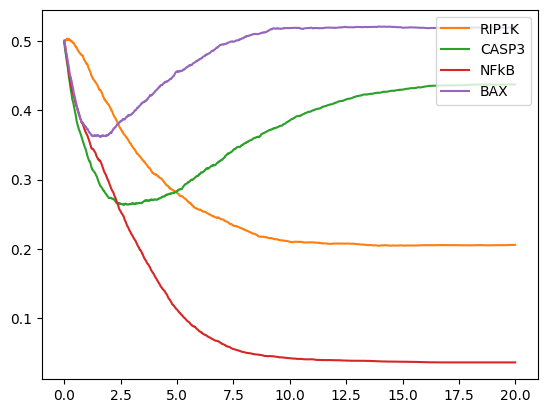

In [55]:
masim_tnf = maboss.load(tnf_simple_bnd, tnf_simple_cfg)

for node in list(masim_tnf.network.keys()):
    masim_tnf.network.set_istate(node, [0.5, 0.5])

masim_tnf.update_parameters(max_time=20, sample_count=10000)

masim_tnf.network.set_output(["BAX", "CASP3", "NFkB", "RIP1K"])

results_tnf = masim_tnf.run()

results_tnf.plot_node_trajectory()

In [56]:
for key, value in dict(results_tnf.get_last_states_probtraj()).items():
    print(key, value)

<nil> 19.9900    0.2748
Name: <nil>, dtype: float64
BAX 19.9900    0.0831
Name: BAX, dtype: float64
CASP3 19.9900    0.000684
Name: CASP3, dtype: float64
CASP3 -- BAX 19.9900    0.435716
Name: CASP3 -- BAX, dtype: float64
CASP3 -- RIP1K 19.9900    0.0007
Name: CASP3 -- RIP1K, dtype: float64
CASP3 -- RIP1K -- BAX 19.9900    0.0003
Name: CASP3 -- RIP1K -- BAX, dtype: float64
RIP1K 19.9900    0.1684
Name: RIP1K, dtype: float64
RIP1K -- BAX 19.9900    0.0005
Name: RIP1K -- BAX, dtype: float64
RIP1K -- NFkB 19.9900    0.0358
Name: RIP1K -- NFkB, dtype: float64


# Scenario 1 - MaBoSS model analysis

In [100]:
bnet_gpt5 = "updated_MCP/Gpt_5/Scenario_1/Network_1.bnet"
bnet_sonnet4 = "updated_MCP/Sonnet_4/Scenario_1/Network_1.bnet"
bnet_gpt_o4 = "updated_MCP/Gpt_o4_mini/Scenario_1/Network_1.bnet"

In [101]:
bnd_gpt5 = "updated_MCP/Gpt_5/Scenario_1/output.bnd"
cfg_gpt5 = "updated_MCP/Gpt_5/Scenario_1/output.cfg"
bnd_sonnet4 = "updated_MCP/Sonnet_4/Scenario_1/output.bnd"
cfg_sonnet4 = "updated_MCP/Sonnet_4/Scenario_1/output.cfg"
bnd_gpt_o4 = "updated_MCP/Gpt_o4_mini/Scenario_1/output.bnd"
cfg_gpt_o4 = "updated_MCP/Gpt_o4_mini/Scenario_1/output.cfg"

In [102]:
masim_gpt5 = maboss.load(bnd_gpt5, cfg_gpt5)
masim_sonnet4 = maboss.load(bnd_sonnet4, cfg_sonnet4)
masim_gpt_o4 = maboss.load(bnd_gpt_o4, cfg_gpt_o4)

In [103]:
for node in list(masim_gpt5.network.keys()):
    masim_gpt5.network.set_istate(node, [0.5, 0.5])

for node in list(masim_sonnet4.network.keys()):
    masim_sonnet4.network.set_istate(node, [0.5, 0.5])

for node in list(masim_gpt_o4.network.keys()):
    masim_gpt_o4.network.set_istate(node, [0.5, 0.5])

In [104]:
masim_gpt5.network.set_output(["CCND1", "MYC", "CASP3", "BAX", "NFKB1"])

masim_gpt5.param["max_time"]=20
masim_gpt5.param["thread_count"]=8

masim_gpt_o4.param["max_time"]=20
masim_gpt_o4.param["thread_count"]=8

masim_gpt_o4.network.set_output(["CCND1", "MYC", "CASP3", "BAX", "NFKB1"])

masim_sonnet4.param["max_time"]=20
masim_sonnet4.param["thread_count"]=8

masim_sonnet4.network.set_output(["CCND1", "MYC", "CASP3", "BAX", "NFKB1"])

In [105]:
results_gpt_o4 = masim_gpt_o4.run()
results_gpt5 = masim_gpt5.run()
results_sonnet4 = masim_sonnet4.run()

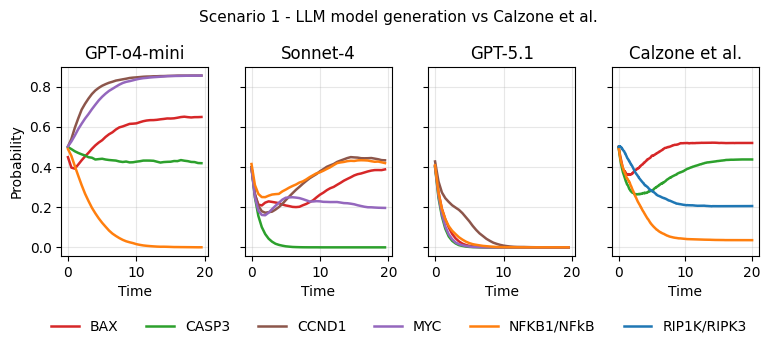

In [112]:
LABEL_ALIASES = {
    "NFkB":  "NFKB1/NFkB",
    "NFKB1": "NFKB1/NFkB",
    "RIP1K": "RIP1K/RIPK3",
    "RIPK3": "RIP1K/RIPK3",
}

def normalize_label(lab):
    return LABEL_ALIASES.get(lab, lab)

def new_figures_after(func):
    """Run func(); return fig objects created by it."""
    before = set(plt.get_fignums())
    func()
    after = set(plt.get_fignums())
    return [plt.figure(n) for n in sorted(after - before)]

def get_label(line):
    lab = line.get_label()
    return None if not lab or lab.startswith("_") else lab

def extract_model_data(figs):
    """Extract {normalized_label: (x, y)} from matplotlib figures.
    When two raw labels map to the same normalized label the first one wins."""
    data = {}
    for f in figs:
        for ax in f.axes:
            for ln in ax.get_lines():
                raw = get_label(ln)
                if raw:
                    lab = normalize_label(raw)
                    if lab not in data:          # keep first occurrence
                        data[lab] = (ln.get_xdata(), ln.get_ydata())
    return data

def build_color_map(*dicts):
    palette = ["#1f77b4","#ff7f0e","#2ca02c","#d62728",
               "#9467bd","#8c564b","#e377c2","#7f7f7f",
               "#bcbd22","#17becf"]
    all_labels = []
    for d in dicts:
        all_labels.extend(list(d.keys()))
    uniq_labels = list(OrderedDict.fromkeys(all_labels))
    return {lab: palette[i % len(palette)] for i, lab in enumerate(uniq_labels)}

# Generate plots (but don't show yet)
plt.ioff()
figs_gpt5      = new_figures_after(lambda: results_gpt5.plot_node_trajectory())
figs_gpto4     = new_figures_after(lambda: results_gpt_o4.plot_node_trajectory())
figs_sonnet4   = new_figures_after(lambda: results_sonnet4.plot_node_trajectory())
figs_tnf_simple = new_figures_after(lambda: results_tnf.plot_node_trajectory())
plt.ion()

# Extract data (labels already normalised inside extract_model_data)
data_gpt5      = extract_model_data(figs_gpt5)
data_gpto4     = extract_model_data(figs_gpto4)
data_sonnet4   = extract_model_data(figs_sonnet4)
data_tnf_simple = extract_model_data(figs_tnf_simple)

# Consistent colors across all panels — fixed paper palette
# Note: aliases produce "RIP1K/RIPK3" (not "RIPK1/RIPK3") in this cell
cmap = build_color_map(data_gpt5, data_gpto4, data_sonnet4, data_tnf_simple)
cmap.update({
    "CASP3":        "#2ca02c",  # green
    "NFKB1/NFkB":   "#ff7f0e",  # orange
    "BAX":          "#d62728",  # red
    "RIP1K/RIPK3":  "#1f77b4",  # blue  (alias output is RIP1K/RIPK3, not RIPK1/RIPK3)
    "MYC":          "#9467bd",  # purple
    "CCND1":        "#8c564b",  # brown
})

# Build the 1×4 composite figure
fig, axes = plt.subplots(1, 4, figsize=(9, 3), sharey=True)
panels = [
    ("GPT-o4-mini",    data_gpto4,      axes[0]),
    ("Sonnet-4",       data_sonnet4,    axes[1]),
    ("GPT-5.1",        data_gpt5,       axes[2]),
    ("Calzone et al.", data_tnf_simple, axes[3]),
]

for title, dct, ax in panels:
    for lab, (x, y) in dct.items():
        ax.plot(x, y, label=lab, color=cmap[lab], linewidth=1.8)
    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Probability")

fig.suptitle("Scenario 1 - LLM model generation vs Calzone et al.", y=1.07, fontsize=11)

# Shared legend: collect unique handles from ALL axes
all_handles = {}
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    for handle, label in zip(h, l):
        if label not in all_handles:
            all_handles[label] = handle

fig.legend(all_handles.values(), all_handles.keys(),
           loc="lower center", ncol=len(all_handles), frameon=False,
           bbox_to_anchor=(0.5, -0.05))

plt.subplots_adjust(bottom=0.25, wspace=0.25)

# Close the original generated figures
for f in figs_gpt5 + figs_gpto4 + figs_sonnet4 + figs_tnf_simple:
    plt.close(f)

plt.show()


# Scenario 1 - PhysiCell config file generator

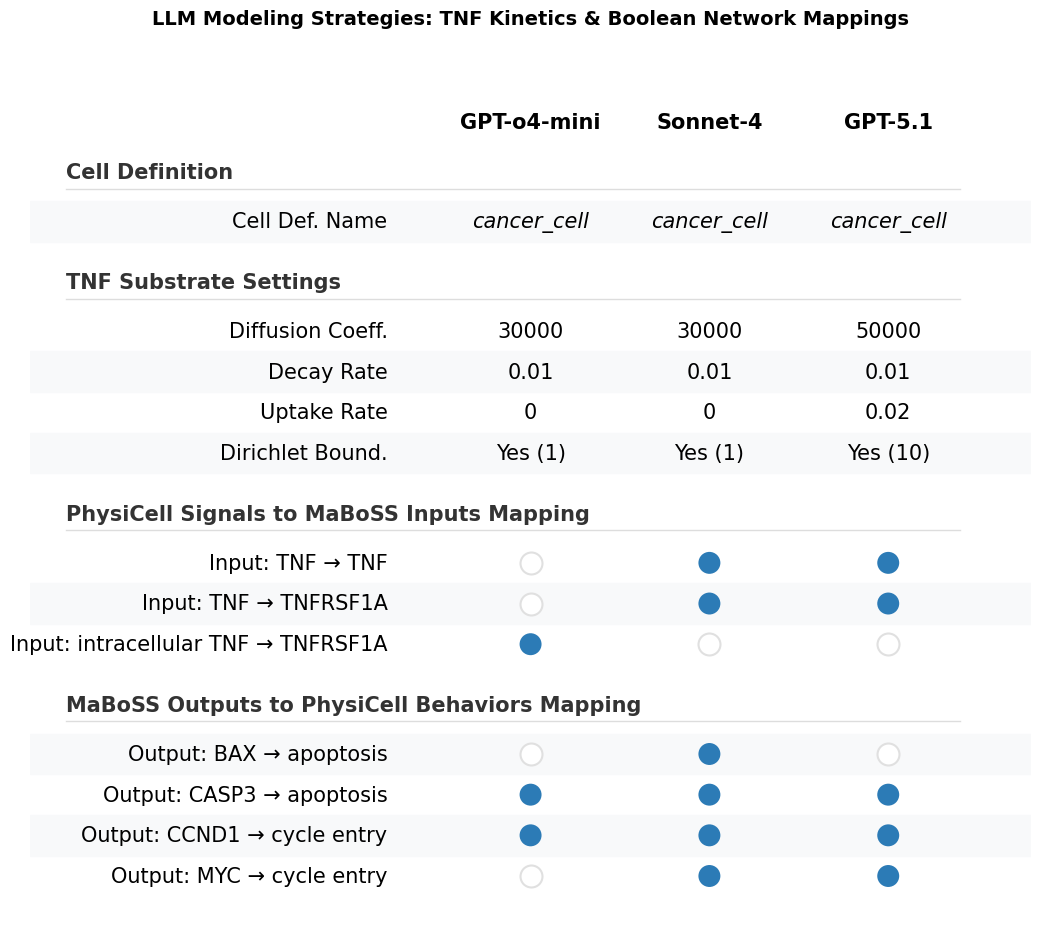

In [157]:
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import numpy as np
import os

# ==============================================================================
# 1. CONFIGURATION & FILE PATHS
# ==============================================================================
XML_FILES = {
    "GPT-o4-mini": "updated_MCP/Gpt_o4_mini/Scenario_1/PhysiCell_settings.xml",
    "Sonnet-4": "updated_MCP/Sonnet_4/Scenario_1/TNF_Cancer_Fate_PhysiCell.xml",
    "GPT-5.1": "updated_MCP/Gpt_5/Scenario_1/PhysiCell_TNF_cancer_tunedTNF.xml"
}

# Aesthetic settings
COLOR_PRIMARY = "#2C7BB6"  
COLOR_MUTED = "#E0E0E0"    
FONT_FAMILY = "sans-serif"
FIG_SIZE = (11, 9.5) # Made slightly taller for the new rows

# ==============================================================================
# 2. DATA EXTRACTION
# ==============================================================================
def extract_model_features(filepath):
    data = {
        "params": {
            "Cell Def. Name": "N/A",
            "Diffusion Coeff.": "N/A", 
            "Decay Rate": "N/A", 
            "Uptake Rate": "N/A",
            "Dirichlet Bound.": "N/A"
        },
        "inputs": set(),
        "outputs": set()
    }
    
    if not os.path.exists(filepath):
        return None

    try:
        tree = ET.parse(filepath)
        root = tree.getroot()
        
        # --- Extract Cell Definition Name ---
        cell_def = root.find(".//cell_definitions/cell_definition")
        if cell_def is not None:
            data["params"]["Cell Def. Name"] = cell_def.get("name", "Unknown")

        # --- Extract TNF Parameters ---
        diff = root.find(".//microenvironment_setup/variable[@name='TNF']/physical_parameter_set/diffusion_coefficient")
        if diff is not None: data["params"]["Diffusion Coeff."] = diff.text.strip()
            
        decay = root.find(".//microenvironment_setup/variable[@name='TNF']/physical_parameter_set/decay_rate")
        if decay is not None: data["params"]["Decay Rate"] = decay.text.strip()
            
        uptake = root.find(".//cell_definitions/cell_definition/phenotype/secretion/substrate[@name='TNF']/uptake_rate")
        if uptake is not None: data["params"]["Uptake Rate"] = uptake.text.strip()

        # --- Extract Dirichlet Condition ---
        dirichlet = root.find(".//microenvironment_setup/variable[@name='TNF']/Dirichlet_boundary_condition")
        if dirichlet is not None:
            is_enabled = dirichlet.get("enabled", "false").lower() == "true"
            val = dirichlet.text.strip() if dirichlet.text else "0"
            data["params"]["Dirichlet Bound."] = f"Yes ({val})" if is_enabled else "No"

        # --- Extract MaBoSS Mappings ---
        for inp in root.findall(".//intracellular[@type='maboss']/mapping/input"):
            data["inputs"].add(f"{inp.get('physicell_name', 'Unknown')} \u2192 {inp.get('intracellular_name', 'Unknown')}")
            
        for out in root.findall(".//intracellular[@type='maboss']/mapping/output"):
            data["outputs"].add(f"{out.get('intracellular_name', 'Unknown')} \u2192 {out.get('physicell_name', 'Unknown')}")

    except Exception as e:
        print(f"Error parsing {filepath}: {e}")
        
    return data

# ==============================================================================
# 3. DATA PROCESSING & FALLBACKS
# ==============================================================================
model_data = {}
all_inputs, all_outputs = set(), set()

for model_name, path in XML_FILES.items():
    extracted = extract_model_features(path)
    if extracted:
        model_data[model_name] = extracted
    else:
        # Fallback simulated data to test the visual layout immediately
        if model_name == "GPT-5":
            model_data[model_name] = {"params": {"Cell Def. Name": "cancer_cell", "Diffusion Coeff.": "50000", "Decay Rate": "0.01", "Uptake Rate": "0.02", "Dirichlet Bound.": "Yes (10)"}, 
                                      "inputs": {"TNF \u2192 TNFRSF1A", "TNF \u2192 TNF"}, 
                                      "outputs": {"CASP3 \u2192 apoptosis", "CCND1 \u2192 cycle entry", "MYC \u2192 cycle entry"}}
        elif model_name == "Sonnet-4":
            model_data[model_name] = {"params": {"Cell Def. Name": "TNF_sensitive_cell", "Diffusion Coeff.": "30000", "Decay Rate": "0.01", "Uptake Rate": "0", "Dirichlet Bound.": "No"}, 
                                      "inputs": {"TNF \u2192 TNFRSF1A", "TNF \u2192 TNF"}, 
                                      "outputs": {"CASP3 \u2192 apoptosis", "BAX \u2192 apoptosis", "CCND1 \u2192 cycle entry", "MYC \u2192 cycle entry"}}
        else:
            model_data[model_name] = {"params": {"Cell Def. Name": "default_cell", "Diffusion Coeff.": "30000", "Decay Rate": "0.01", "Uptake Rate": "0", "Dirichlet Bound.": "Yes (5)"}, 
                                      "inputs": {"intracellular TNF \u2192 TNFRSF1A"}, 
                                      "outputs": {"CASP3 \u2192 apoptosis", "CCND1 \u2192 cycle entry"}}

    all_inputs.update(model_data[model_name]["inputs"])
    all_outputs.update(model_data[model_name]["outputs"])

sorted_inputs = sorted(list(all_inputs))
sorted_outputs = sorted(list(all_outputs))
models = list(XML_FILES.keys())

# ==============================================================================
# 4. PLOTTING THE PUBLICATION FIGURE (TOP-TO-BOTTOM LAYOUT)
# ==============================================================================
plt.rcParams["font.family"] = FONT_FAMILY
fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.axis('off')

# Set up coordinates to prevent overlap
x_header = 0       
x_labels = 4.5     
x_positions = {model: 6.5 + i * 2.5 for i, model in enumerate(models)} 

y_positions = {}
header_positions = {}
current_y = 0

# --- Section 1: Cellular Agents ---
header_positions["Cell Definition"] = current_y
current_y -= 1.2
y_positions["Cell Def. Name"] = current_y
current_y -= 1
current_y -= 0.5

# --- Section 2: TNF Parameters ---
header_positions["TNF Substrate Settings"] = current_y
current_y -= 1.2
for param in ["Diffusion Coeff.", "Decay Rate", "Uptake Rate", "Dirichlet Bound."]:
    y_positions[param] = current_y
    current_y -= 1
current_y -= 0.5

# --- Section 3: Inputs ---
header_positions["PhysiCell Signals to MaBoSS Inputs Mapping"] = current_y
current_y -= 1.2
for in_feat in sorted_inputs:
    y_positions[f"In: {in_feat}"] = current_y
    current_y -= 1
current_y -= 0.5

# --- Section 4: Outputs ---
header_positions["MaBoSS Outputs to PhysiCell Behaviors Mapping"] = current_y
current_y -= 1.2
for out_feat in sorted_outputs:
    y_positions[f"Out: {out_feat}"] = current_y
    current_y -= 1

# Draw subtle alternating row backgrounds for the data rows (skipping headers)
for i, y in enumerate(y_positions.values()):
    if i % 2 == 0:
        ax.axhspan(y - 0.5, y + 0.5, color='#F8F9FA', zorder=0)

# Draw the Headers
for header, y in header_positions.items():
    ax.text(x_header, y, header, ha='left', va='center', fontsize=15, fontweight='bold', color='#333333')
    # Subtle divider line under headers
    ax.plot([x_header, max(x_positions.values()) + 1], [y - 0.4, y - 0.4], color='#DDDDDD', lw=1, zorder=1)

# Draw the Row Labels
for label, y in y_positions.items():
    clean_label = label.replace("In: ", "Input: ").replace("Out: ", "Output: ")
    ax.text(x_labels, y, clean_label, ha='right', va='center', fontsize=15)

# Plot Data
for model in models:
    x = x_positions[model]
    
    # Draw Model Names (Column Headers)
    ax.text(x, 1, model, ha='center', va='bottom', fontsize=15, fontweight='bold')
    
    # 1. Plot Parameters (Text)
    params = model_data[model]["params"]
    ax.text(x, y_positions["Cell Def. Name"], params["Cell Def. Name"], ha='center', va='center', fontsize=15, style='italic')
    ax.text(x, y_positions["Diffusion Coeff."], params["Diffusion Coeff."], ha='center', va='center', fontsize=15)
    ax.text(x, y_positions["Decay Rate"], params["Decay Rate"], ha='center', va='center', fontsize=15)
    ax.text(x, y_positions["Uptake Rate"], params["Uptake Rate"], ha='center', va='center', fontsize=15)
    ax.text(x, y_positions["Dirichlet Bound."], params["Dirichlet Bound."], ha='center', va='center', fontsize=15)
    
    # 2. Plot Inputs (Dots)
    for in_feat in sorted_inputs:
        y = y_positions[f"In: {in_feat}"]
        if in_feat in model_data[model]["inputs"]:
            ax.scatter(x, y, s=250, color=COLOR_PRIMARY, edgecolors='none', zorder=3)
        else:
            ax.scatter(x, y, s=250, color='white', edgecolors=COLOR_MUTED, linewidth=1.5, zorder=3)
            
    # 3. Plot Outputs (Dots)
    for out_feat in sorted_outputs:
        y = y_positions[f"Out: {out_feat}"]
        if out_feat in model_data[model]["outputs"]:
            ax.scatter(x, y, s=250, color=COLOR_PRIMARY, edgecolors='none', zorder=3)
        else:
            ax.scatter(x, y, s=250, color='white', edgecolors=COLOR_MUTED, linewidth=1.5, zorder=3)

# Main Title
plt.title("LLM Modeling Strategies: TNF Kinetics & Boolean Network Mappings", 
          fontsize=14, fontweight='bold', pad=30, y=1.03)

# Dynamically set limits so nothing is cut off
ax.set_xlim(-0.5, max(x_positions.values()) + 2)
ax.set_ylim(current_y - 0.5, 2)

plt.tight_layout()
# plt.savefig("LLM_Strategy_Grid_Final.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [96]:
from pctk import multicellds

In [97]:
gpt_5_output = "PhysiCell_output/Gpt_5.1_scenario_1/"
sonnet4_output = "PhysiCell_output/Sonnet_4_scenario_1/"
gpt_o4_output = "PhysiCell_output/Gpt_o4_mini_scenario_1/"

reader_gpt5 = multicellds.MultiCellDS(output_folder=gpt_5_output)
reader_sonnet4 = multicellds.MultiCellDS(output_folder=sonnet4_output)
reader_gpt_o4 = multicellds.MultiCellDS(output_folder=gpt_o4_output)

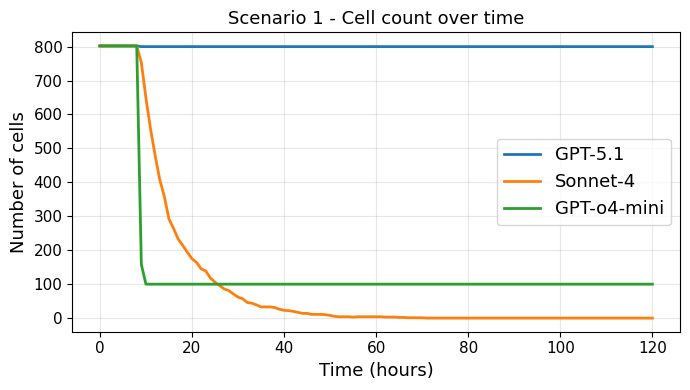

In [98]:

def collect_cell_counts(reader):
    times, counts = [], []
    for t, mat in reader.cells_as_matrix_iterator():
        times.append(t / 60)   # minutes → hours
        counts.append(mat.shape[0])
    return times, counts

times_gpt5,    counts_gpt5    = collect_cell_counts(reader_gpt5)
times_sonnet4, counts_sonnet4 = collect_cell_counts(reader_sonnet4)
times_gpt_o4,  counts_gpt_o4  = collect_cell_counts(reader_gpt_o4)

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(times_gpt5,    counts_gpt5,    label="GPT-5.1",       linewidth=2)
ax.plot(times_sonnet4, counts_sonnet4, label="Sonnet-4",    linewidth=2)
ax.plot(times_gpt_o4,  counts_gpt_o4,  label="GPT-o4-mini", linewidth=2)

ax.set_xlabel("Time (hours)", fontsize=13)
ax.set_ylabel("Number of cells", fontsize=13)
ax.set_title("Scenario 1 - Cell count over time", fontsize=13)
ax.legend(frameon=True, fontsize=13)
ax.tick_params(axis='both', labelsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("scenario1_cell_count.png", dpi=300, bbox_inches="tight")
plt.show()


# Scenario 2 analysis

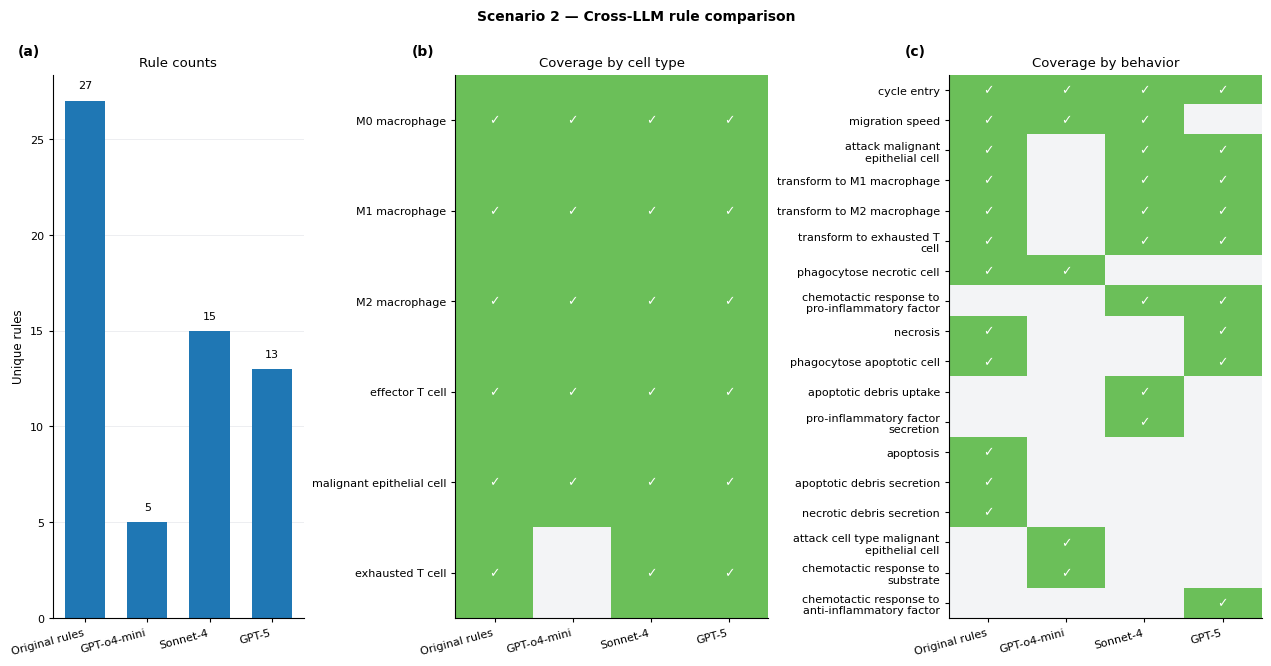

Saved: scenario2_rules_dashboard_light.pdf and scenario2_rules_dashboard_light.png


In [43]:
# === Cross-LLM Rules Dashboard — light, Nature-friendly styling ===
# Panels: (a) Unique rule counts  (b) Coverage by cell type  (c) Coverage by behavior

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import textwrap

# ---- INPUT ----
output_gpt5 =  "updated_MCP/Gpt_5/Scenario_2/cell_rules_auto.csv"
output_sonnet4 = "updated_MCP/Sonnet_4/Scenario_2/cell_rules_enhanced.csv"
output_gpt_o4 = "updated_MCP/Gpt_o4_mini/Scenario_2/cell_rules_updated.csv"
original_rules = "cell_rules.csv"

MODEL_NAMES = {
    original_rules: "Original rules",
    output_gpt_o4:  "GPT-o4-mini",
    output_sonnet4: "Sonnet-4",
    output_gpt5:    "GPT-5"
}
HAS_HEADER       = False
TOPK_CELLTYPES   = 8     # reduce if labels still feel crowded
TOPK_BEHAVIORS   = 22
MAX_LABEL_WIDTH  = 26
SAVE_BASENAME    = "scenario2_rules_dashboard_light"

# ---- STYLE ----
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 8.5,
    "axes.titlesize": 9.5,
    "axes.labelsize": 8.5,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "savefig.dpi": 600,
})

# palette (closer to your original)
ACCENT  = "#1f77b4"   # bars
PRESENT = "#6bbf59"   # soft green (was darker before)
ABSENT  = "#f3f4f6"   # very light gray
CHECK   = "white"

# ---- LOAD ----
def load_rules(path: str, model_name: str, has_header=False) -> pd.DataFrame:
    df = pd.read_csv(path, header=None if not has_header else 0)
    if df.shape[1] < 4:
        raise ValueError(f"{path} has only {df.shape[1]} columns; expected ≥4.")
    df = df.iloc[:, :4].copy()
    df.columns = ["cell_type", "signal", "direction", "behavior"]
    for c in df.columns:
        df[c] = (df[c].astype(str)
                        .str.strip()
                        .str.replace(r"\s+", " ", regex=True))
    df["model"] = model_name
    df["rule_key"] = list(zip(df["cell_type"].str.lower(),
                              df["signal"].str.lower(),
                              df["direction"].str.lower(),
                              df["behavior"].str.lower()))
    df = df.drop_duplicates(subset=["rule_key"])
    return df

frames = [load_rules(Path(p), MODEL_NAMES[p], HAS_HEADER) for p in MODEL_NAMES]
data = pd.concat(frames, ignore_index=True)
models = list(MODEL_NAMES.values())

# ---- COVERAGE MATRICES ----
def presence_matrix(df: pd.DataFrame, item_col: str, topk: int) -> pd.DataFrame:
    counts = (df.groupby([item_col, "model"])["rule_key"]
                .nunique()
                .reset_index(name="n"))
    top_items = (counts.groupby(item_col)["n"].sum()
                 .sort_values(ascending=False).head(topk).index.tolist())
    counts = counts[counts[item_col].isin(top_items)]
    pres = counts.pivot(index=item_col, columns="model", values="n").fillna(0).astype(int)
    pres = (pres > 0).astype(int)
    pres["__sum"] = pres.sum(axis=1)
    pres = pres.sort_values(["__sum", *pres.columns[:-1]], ascending=[False, *([True]*len(models))])
    pres = pres.drop(columns="__sum").reindex(columns=models)
    return pres

pres_cell = presence_matrix(data, "cell_type", TOPK_CELLTYPES)
pres_beh  = presence_matrix(data, "behavior",  TOPK_BEHAVIORS)

# ---- UTILS ----
def wrap_labels(labels, width=24):
    return ["\n".join(textwrap.wrap(str(s), width=width, break_long_words=False)) for s in labels]

def panel_tag(ax, tag):
    ax.text(-0.14, 1.03, tag, transform=ax.transAxes,
            ha="left", va="bottom", fontsize=10, fontweight="bold")

# Slightly taller figure to reduce crowding
fig = plt.figure(figsize=(12.6, 6.2), constrained_layout=True)
gs  = fig.add_gridspec(nrows=1, ncols=3, width_ratios=[1.0, 1.25, 1.25])

# (a) counts
ax0 = fig.add_subplot(gs[0,0])
counts_per_model = (data.groupby("model")["rule_key"].nunique().reindex(models))
bars = ax0.bar(counts_per_model.index, counts_per_model.values, color=ACCENT, width=0.65)
ax0.set_ylabel("Unique rules")
ax0.set_title("Rule counts", pad=6)
ax0.yaxis.grid(True, color="#e5e7eb", linewidth=0.6, alpha=0.8)
ax0.set_axisbelow(True)
for t in ax0.get_xticklabels():
    t.set_rotation(15)
    t.set_ha("right")
for r in bars:
    ax0.text(r.get_x()+r.get_width()/2, r.get_height()+max(0.5, r.get_height()*0.02),
             f"{int(r.get_height())}", ha="center", va="bottom", fontsize=8)
panel_tag(ax0, "(a)")

# binary heatmap helper (green/gray + checkmarks)
def binary_heatmap(ax, pres_df: pd.DataFrame, title: str):
    ax.set_title(title, pad=6)
    cmap = ListedColormap([ABSENT, PRESENT])
    im = ax.imshow(pres_df.values, aspect="auto", cmap=cmap, vmin=0, vmax=1)
    ax.set_yticks(range(len(pres_df.index)))
    ax.set_yticklabels(wrap_labels(pres_df.index, width=MAX_LABEL_WIDTH))
    ax.set_xticks(range(len(pres_df.columns)))
    ax.set_xticklabels(pres_df.columns, rotation=0)
    # minimal box, no clutter
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    # add checkmarks only where present
    for i in range(pres_df.shape[0]):
        for j in range(pres_df.shape[1]):
            if pres_df.iat[i, j] == 1:
                ax.text(j, i, "✓", ha="center", va="center",
                        fontsize=9, color=CHECK, fontweight="bold")

# (b) cell types
ax1 = fig.add_subplot(gs[0,1])
binary_heatmap(ax1, pres_cell, "Coverage by cell type")
panel_tag(ax1, "(b)")
for t in ax1.get_xticklabels():
    t.set_rotation(15)
    t.set_ha("right")

# (c) behaviors
ax2 = fig.add_subplot(gs[0,2])
binary_heatmap(ax2, pres_beh, "Coverage by behavior")
panel_tag(ax2, "(c)")
for t in ax2.get_xticklabels():
    t.set_rotation(15)
    t.set_ha("right")

fig.suptitle("Scenario 2 — Cross-LLM rule comparison", y=1.05, fontsize=10, fontweight="bold")
plt.show()

# Save vector + PNG
Path(f"{SAVE_BASENAME}.pdf").write_bytes(b"")  # ensure path exists on some envs
fig.savefig(f"{SAVE_BASENAME}.pdf", bbox_inches="tight")
fig.savefig(f"{SAVE_BASENAME}.png", bbox_inches="tight")
print("Saved:", f"{SAVE_BASENAME}.pdf", "and", f"{SAVE_BASENAME}.png")


Total unique rules across all models: 48


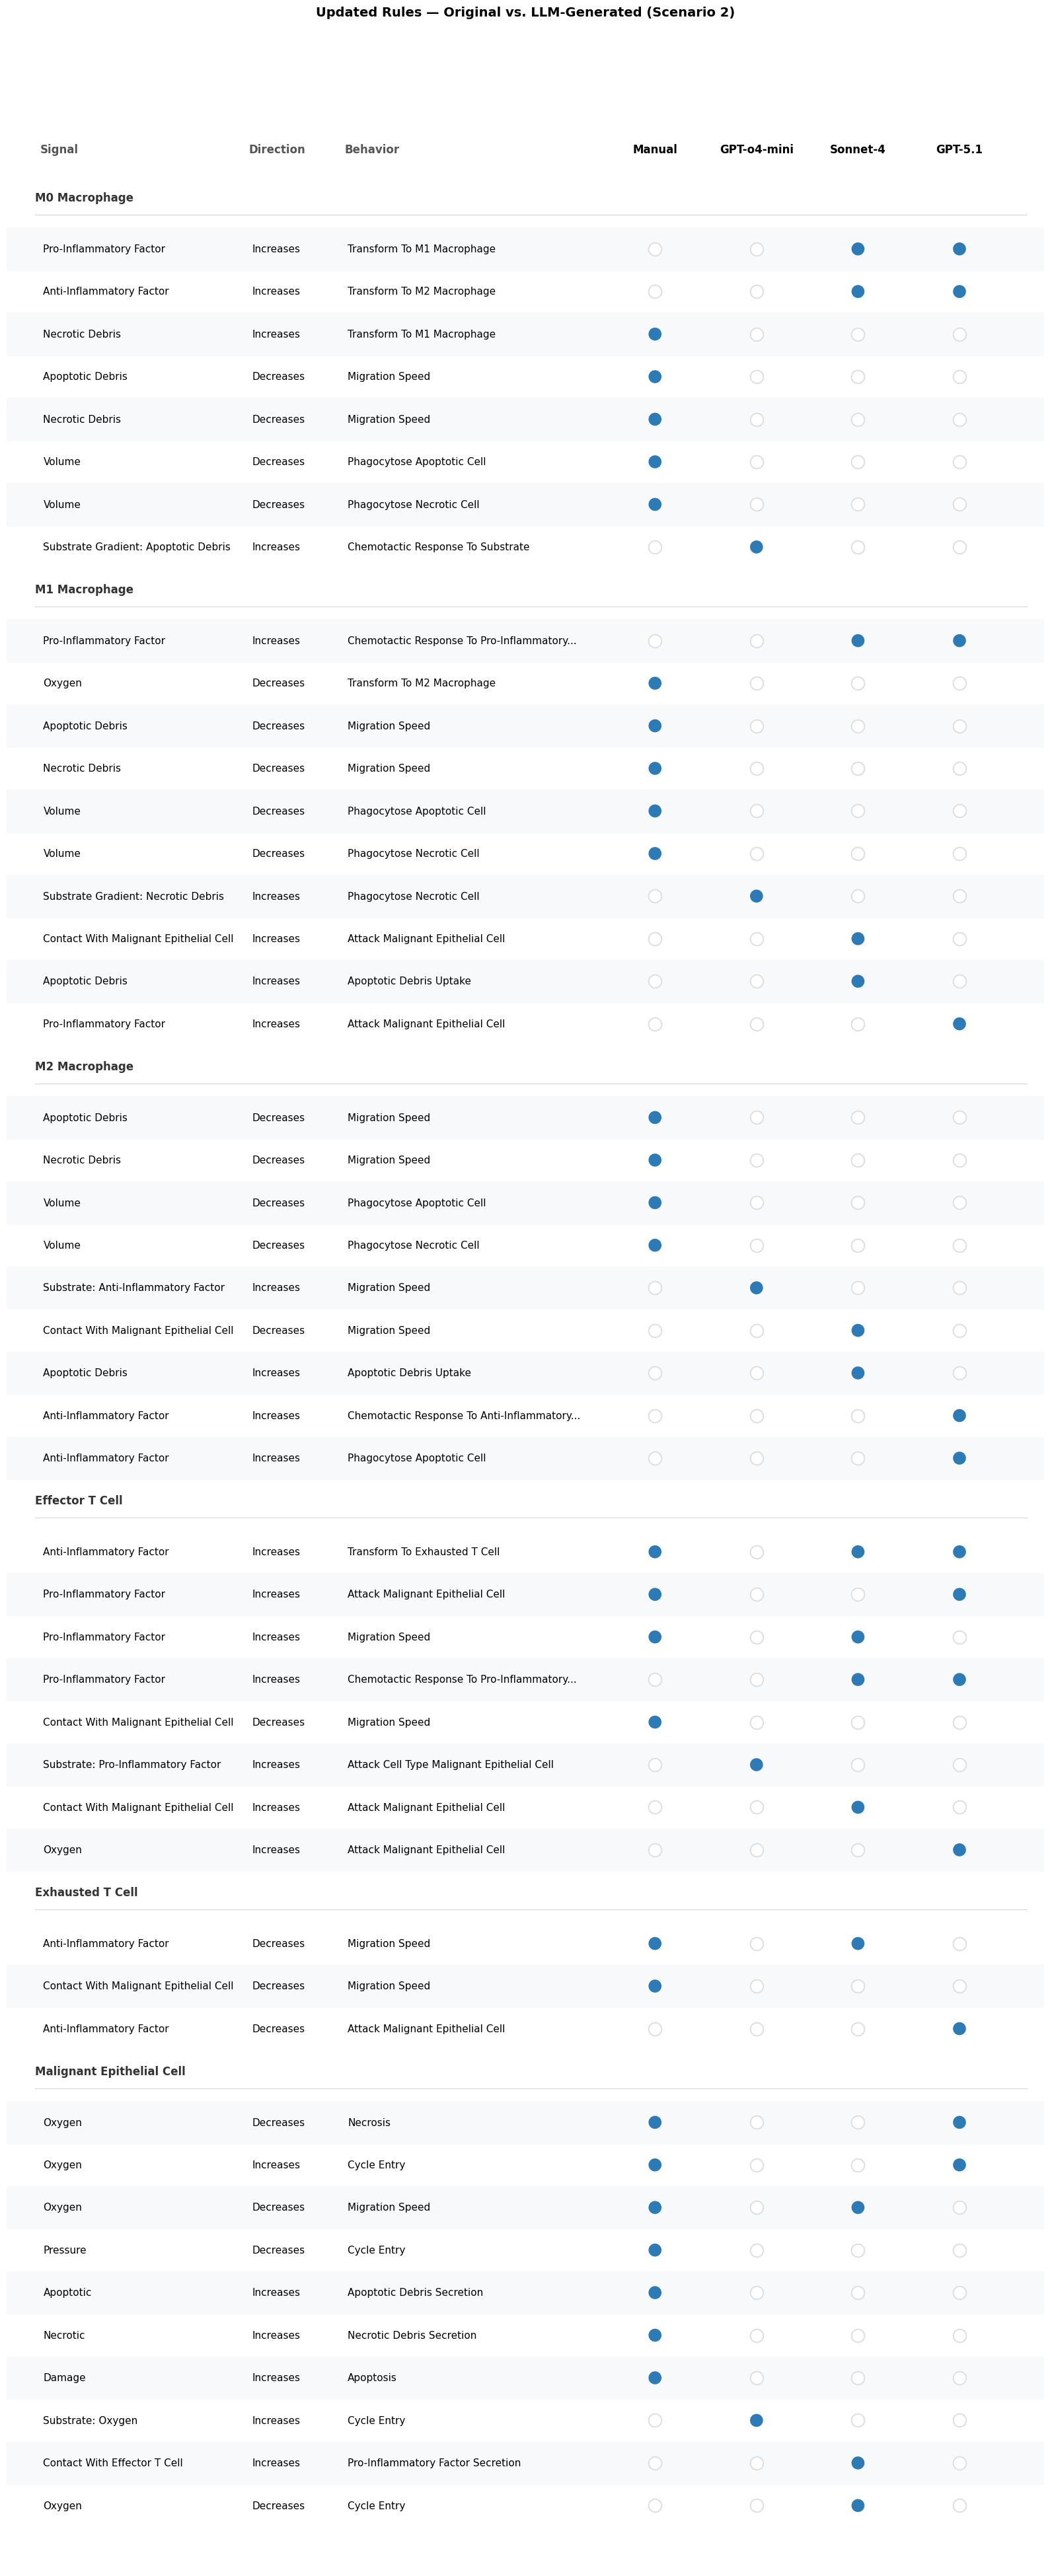

Saved: rules_table_updated.pdf / .png
LaTeX table written to: rules_table_updated.tex


In [132]:

# === Updated Rules Matrix — Dot-matrix style (matching Scenario 1 figure) ===
# Filled blue dots = rule present, open circles = absent.
# Grouped by cell type with bold section headers.

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

# ---- FILE PATHS ----
FILES = {
    "Manual":      "cell_rules.csv",
    "GPT-o4-mini": "updated_MCP/Gpt_o4_mini/Scenario_2/cell_rules_updated.csv",
    "Sonnet-4":    "updated_MCP/Sonnet_4/Scenario_2/cell_rules_enhanced.csv",
    "GPT-5.1":       "updated_MCP/Gpt_5/Scenario_2/cell_rules_auto.csv",
}
LATEX_OUT = "rules_table_updated.tex"

# ---- STYLE (matches Scenario 1 figure) ----
COLOR_PRIMARY = "#2C7BB6"
COLOR_MUTED   = "#E0E0E0"
FONT_FAMILY   = "sans-serif"

# ---- LOAD & NORMALISE ----
def load_rules(path, model_name):
    df = pd.read_csv(path, header=None)
    df = df.iloc[:, :4].copy()
    df.columns = ["cell_type", "signal", "direction", "behavior"]
    for c in df.columns:
        df[c] = df[c].astype(str).str.strip().str.replace(r"\s+", " ", regex=True)
    df["model"] = model_name
    df["rule_key"] = list(zip(
        df["cell_type"].str.lower(),
        df["signal"].str.lower(),
        df["direction"].str.lower(),
        df["behavior"].str.lower(),
    ))
    return df.drop_duplicates(subset=["rule_key"])

frames = [load_rules(p, m) for m, p in FILES.items()]
data   = pd.concat(frames, ignore_index=True)
models = list(FILES.keys())

# ---- BUILD PRESENCE MATRIX ----
all_rules = (data[["cell_type", "signal", "direction", "behavior", "rule_key"]]
             .drop_duplicates(subset=["rule_key"]))

m_keys_cache = {m: set(data[data["model"] == m]["rule_key"]) for m in models}

rows = []
for _, r in all_rules.iterrows():
    entry = {k: r[k] for k in ["cell_type", "signal", "direction", "behavior"]}
    for m in models:
        entry[m] = 1 if r["rule_key"] in m_keys_cache[m] else 0
    rows.append(entry)

matrix = pd.DataFrame(rows)
matrix["n_models"] = matrix[models].sum(axis=1)
matrix = (matrix
          .sort_values(["cell_type", "n_models"], ascending=[True, False])
          .reset_index(drop=True))

print(f"Total unique rules across all models: {len(matrix)}")

# ---- LAYOUT: compute y positions ----
y_positions      = {}
header_positions = {}

current_y = 0
prev_ct   = None

for i, (_, row) in enumerate(matrix.iterrows()):
    ct = row["cell_type"]
    if ct != prev_ct:
        header_positions[ct] = current_y
        current_y -= 1.2
        prev_ct = ct
    y_positions[i] = current_y
    current_y -= 1.0

# ---- FIGURE ----
plt.rcParams["font.family"] = FONT_FAMILY

fig_h = max(10, abs(current_y) * 0.65 + 3)
fig, ax = plt.subplots(figsize=(16, fig_h))
ax.axis("off")

# x layout — Signal | Direction | Behavior (wider) | Models (narrower spacing)
x_header = 0
x_sig    = 0.1    # signal left-aligned
x_dir    = 3.8    # direction left-aligned
x_beh    = 5.5    # behavior left-aligned (wider: models pushed to 11.0+)
x_positions = {model: 11.0 + i * 1.8 for i, model in enumerate(models)}

# Alternating row backgrounds
for i, y in y_positions.items():
    if i % 2 == 0:
        ax.axhspan(y - 0.5, y + 0.5, color="#F8F9FA", zorder=0)

# Column headers
for lbl, x in zip(["Signal", "Direction", "Behavior"], [x_sig, x_dir, x_beh]):
    ax.text(x, 1.0, lbl, ha="left", va="bottom", fontsize=12,
            fontweight="bold", color="#555555")
for model, x in x_positions.items():
    ax.text(x, 1.0, model, ha="center", va="bottom", fontsize=12, fontweight="bold")

# Section headers (cell types) with divider lines
for ct, y in header_positions.items():
    ax.text(x_header, y, ct.title(), ha="left", va="center",
            fontsize=12, fontweight="bold", color="#333333")
    ax.plot([x_header, max(x_positions.values()) + 1.2],
            [y - 0.4, y - 0.4], color="#DDDDDD", lw=1, zorder=1)

def shorten(s, n=45):
    return textwrap.shorten(s.title(), width=n, placeholder="...")

# Data rows
for i, (_, row) in enumerate(matrix.iterrows()):
    y = y_positions[i]
    ax.text(x_sig + 0.05, y, shorten(row["signal"]),   ha="left", va="center", fontsize=11)
    ax.text(x_dir + 0.05, y, row["direction"].title(), ha="left", va="center", fontsize=11)
    ax.text(x_beh + 0.05, y, shorten(row["behavior"]), ha="left", va="center", fontsize=11)

    for model, x in x_positions.items():
        if row[model] == 1:
            ax.scatter(x, y, s=200, color=COLOR_PRIMARY, edgecolors="none", zorder=3)
        else:
            ax.scatter(x, y, s=200, color="white", edgecolors=COLOR_MUTED,
                       linewidth=1.5, zorder=3)

plt.title("Updated Rules — Original vs. LLM-Generated (Scenario 2)",
          fontsize=14, fontweight="bold", pad=25, y=1.03)

ax.set_xlim(-0.5, max(x_positions.values()) + 1.5)
ax.set_ylim(current_y - 0.5, 2)

plt.tight_layout()
plt.savefig("rules_table_updated.pdf", dpi=300, bbox_inches="tight")
plt.savefig("rules_table_updated.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: rules_table_updated.pdf / .png")


# ---- LATEX EXPORT ----
def tex_escape(s):
    return (str(s)
            .replace("\\", "\\textbackslash ")
            .replace("&",  "\\&")
            .replace("%",  "\\%")
            .replace("_",  "\\_")
            .replace("#",  "\\#")
            .replace("$",  "\\$")
            .replace("{",  "\\{")
            .replace("}",  "\\}")
            .title())

lines = [
    r"\begin{table*}[htbp]",
    r"\centering",
    (r"\caption{Rule-by-rule comparison of updated LLM-generated rules, grouped by cell type. "
     r"\textbf{\checkmark} indicates rule is present, --- indicates absent. "
     r"The files (rules.csv) with all the rules generated by the LLMs can be found at "
     r"\url{https://github.com/marcorusc/Supp_mat_MCP_orchestrator}}"),
    r"\label{tab:rules_matrix_updated}",
    r"\small",
    r"\begin{tabular}{p{4.5cm}p{1.3cm}p{4.5cm}cccc}",
    r"\toprule",
    r"Signal & Direction & Behavior & Manual & GPT-o4-mini & Sonnet-4 & GPT-5 \\",
    r"\midrule",
]

prev_ct = None
for _, row in matrix.iterrows():
    ct = row["cell_type"]
    if ct != prev_ct:
        if prev_ct is not None:
            lines.append(r"\midrule")
        lines.append(f"\\multicolumn{{7}}{{l}}{{\\textbf{{{tex_escape(ct)}}}}} \\\\")
        lines.append(r"\midrule")
        prev_ct = ct
    sig  = tex_escape(row["signal"])
    dir_ = tex_escape(row["direction"])
    beh  = tex_escape(row["behavior"])
    cols = " & ".join(r"\checkmark" if row[m] else "---" for m in models)
    lines.append(f"{sig} & {dir_} & {beh} & {cols} \\\\")

lines += [r"\bottomrule", r"\end{tabular}", r"\end{table*}"]
Path(LATEX_OUT).write_text("\n".join(lines))
print(f"LaTeX table written to: {LATEX_OUT}")


Rows after filtering (Manual-only rows removed): 28


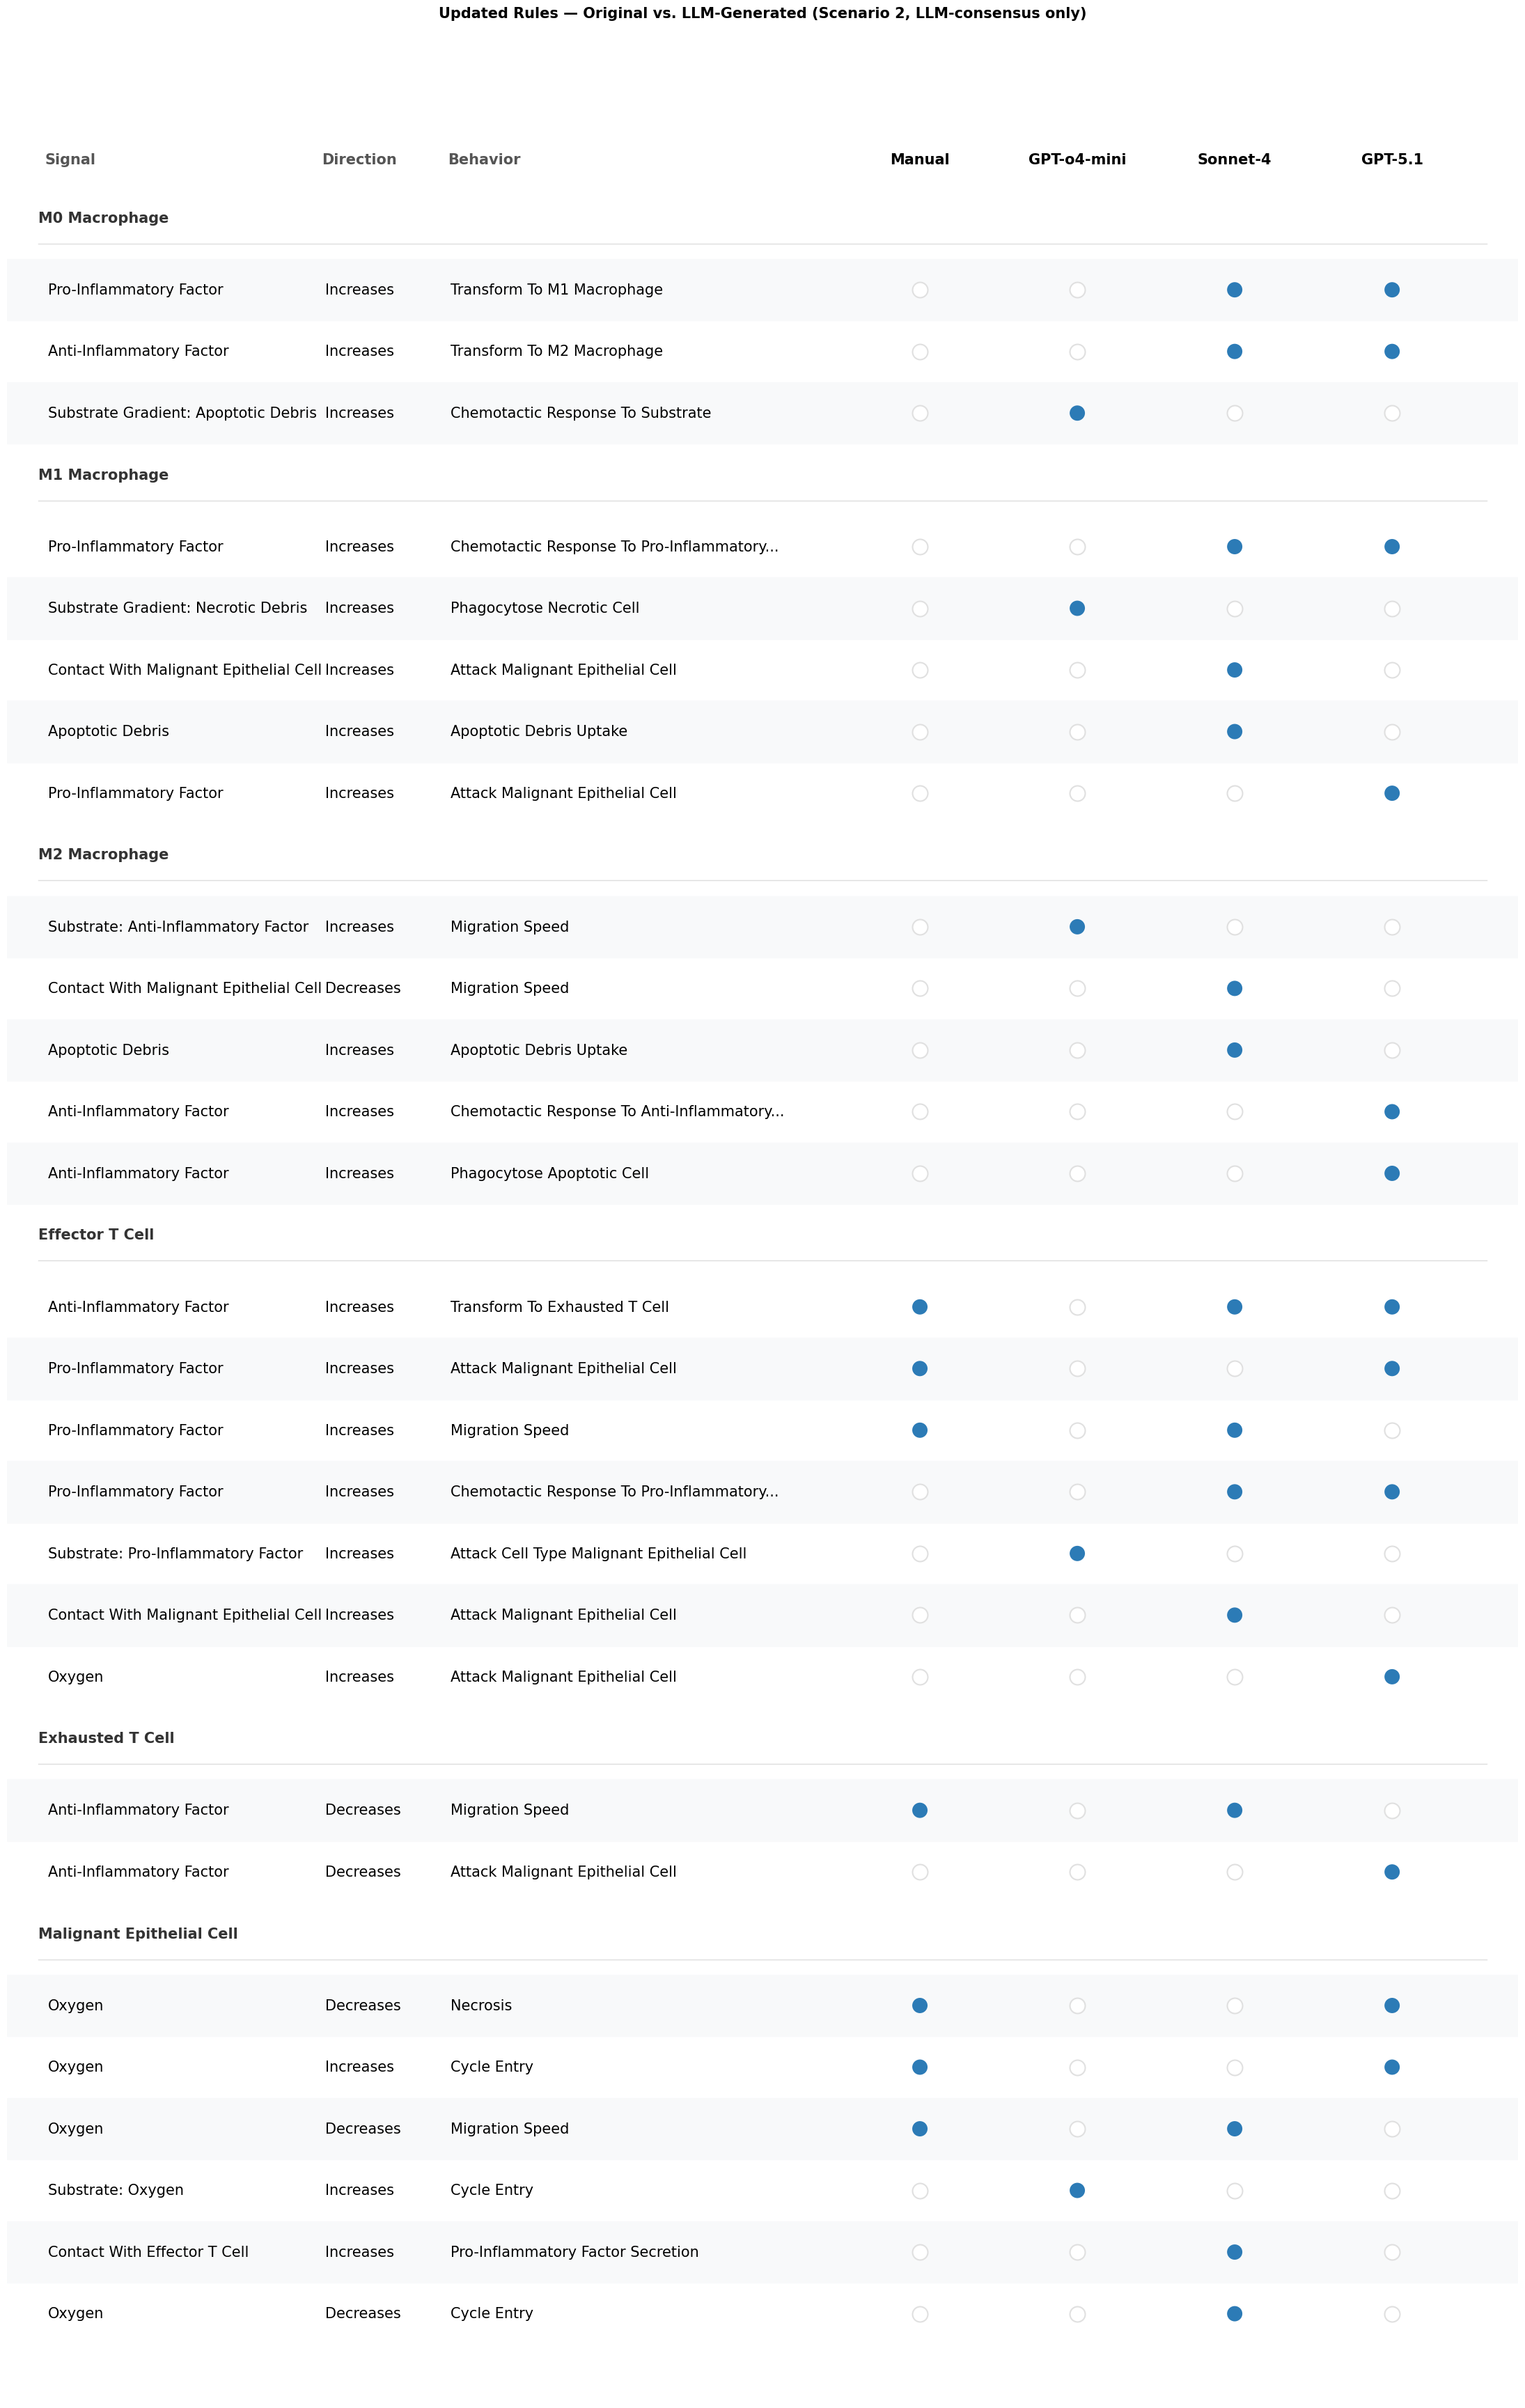

Saved: rules_table_updated_filtered.pdf / .png
LaTeX table written to: rules_table_updated_filtered.tex


In [133]:

# === Updated Rules Matrix — Large-font version, LLM-consensus rows only ===
# Same dot-matrix style but fontsize=15 (matching Scenario 1 PhysiCell figure).
# Rows where Manual=present but ALL three LLMs are absent are removed.

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

# ---- FILE PATHS ----
FILES = {
    "Manual":      "cell_rules.csv",
    "GPT-o4-mini": "updated_MCP/Gpt_o4_mini/Scenario_2/cell_rules_updated.csv",
    "Sonnet-4":    "updated_MCP/Sonnet_4/Scenario_2/cell_rules_enhanced.csv",
    "GPT-5.1":       "updated_MCP/Gpt_5/Scenario_2/cell_rules_auto.csv",
}
LATEX_OUT_FILTERED = "rules_table_updated_filtered.tex"

COLOR_PRIMARY = "#2C7BB6"
COLOR_MUTED   = "#E0E0E0"
FONT_FAMILY   = "sans-serif"
FONT_SZ       = 15   # matches the Scenario 1 reference figure

# ---- LOAD & NORMALISE ----
def load_rules_v2(path, model_name):
    df = pd.read_csv(path, header=None)
    df = df.iloc[:, :4].copy()
    df.columns = ["cell_type", "signal", "direction", "behavior"]
    for c in df.columns:
        df[c] = df[c].astype(str).str.strip().str.replace(r"\s+", " ", regex=True)
    df["model"] = model_name
    df["rule_key"] = list(zip(
        df["cell_type"].str.lower(),
        df["signal"].str.lower(),
        df["direction"].str.lower(),
        df["behavior"].str.lower(),
    ))
    return df.drop_duplicates(subset=["rule_key"])

frames = [load_rules_v2(p, m) for m, p in FILES.items()]
data2   = pd.concat(frames, ignore_index=True)
models  = list(FILES.keys())
llm_models = [m for m in models if m != "Manual"]

m_keys2 = {m: set(data2[data2["model"] == m]["rule_key"]) for m in models}

all_rules2 = (data2[["cell_type", "signal", "direction", "behavior", "rule_key"]]
              .drop_duplicates(subset=["rule_key"]))

rows2 = []
for _, r in all_rules2.iterrows():
    entry = {k: r[k] for k in ["cell_type", "signal", "direction", "behavior"]}
    for m in models:
        entry[m] = 1 if r["rule_key"] in m_keys2[m] else 0
    rows2.append(entry)

matrix2 = pd.DataFrame(rows2)
matrix2["n_models"] = matrix2[models].sum(axis=1)
matrix2 = (matrix2
           .sort_values(["cell_type", "n_models"], ascending=[True, False])
           .reset_index(drop=True))

# ---- FILTER: remove rows where Manual=1 but all LLMs are absent ----
llm_sum = matrix2[llm_models].sum(axis=1)
mask = ~((matrix2["Manual"] == 1) & (llm_sum == 0))
matrix2 = matrix2[mask].reset_index(drop=True)

print(f"Rows after filtering (Manual-only rows removed): {len(matrix2)}")

# ---- LAYOUT ----
y_positions2      = {}
header_positions2 = {}
current_y2 = 0
prev_ct    = None

for i, (_, row) in enumerate(matrix2.iterrows()):
    ct = row["cell_type"]
    if ct != prev_ct:
        header_positions2[ct] = current_y2
        current_y2 -= 1.4
        prev_ct = ct
    y_positions2[i] = current_y2
    current_y2 -= 1.2

# ---- FIGURE ----
plt.rcParams["font.family"] = FONT_FAMILY

fig_h = max(12, abs(current_y2) * 0.75 + 3)
fig, ax = plt.subplots(figsize=(22, fig_h))
ax.axis("off")

x_header = 0
x_sig    = 0.1
x_dir    = 4.5
x_beh    = 6.5
x_positions2 = {model: 14.0 + i * 2.5 for i, model in enumerate(models)}

# Alternating row backgrounds
for i, y in y_positions2.items():
    if i % 2 == 0:
        ax.axhspan(y - 0.6, y + 0.6, color="#F8F9FA", zorder=0)

# Column headers
for lbl, x in zip(["Signal", "Direction", "Behavior"], [x_sig, x_dir, x_beh]):
    ax.text(x, 1.0, lbl, ha="left", va="bottom", fontsize=FONT_SZ,
            fontweight="bold", color="#555555")
for model, x in x_positions2.items():
    ax.text(x, 1.0, model, ha="center", va="bottom", fontsize=FONT_SZ, fontweight="bold")

# Section headers (cell types) with divider lines
for ct, y in header_positions2.items():
    ax.text(x_header, y, ct.title(), ha="left", va="center",
            fontsize=FONT_SZ, fontweight="bold", color="#333333")
    ax.plot([x_header, max(x_positions2.values()) + 1.5],
            [y - 0.5, y - 0.5], color="#DDDDDD", lw=1, zorder=1)

def shorten(s, n=45):
    return textwrap.shorten(s.title(), width=n, placeholder="...")

for i, (_, row) in enumerate(matrix2.iterrows()):
    y = y_positions2[i]
    ax.text(x_sig + 0.05, y, shorten(row["signal"]),   ha="left", va="center", fontsize=FONT_SZ)
    ax.text(x_dir + 0.05, y, row["direction"].title(), ha="left", va="center", fontsize=FONT_SZ)
    ax.text(x_beh + 0.05, y, shorten(row["behavior"]), ha="left", va="center", fontsize=FONT_SZ)

    for model, x in x_positions2.items():
        if row[model] == 1:
            ax.scatter(x, y, s=250, color=COLOR_PRIMARY, edgecolors="none", zorder=3)
        else:
            ax.scatter(x, y, s=250, color="white", edgecolors=COLOR_MUTED,
                       linewidth=1.5, zorder=3)

plt.title("Updated Rules — Original vs. LLM-Generated (Scenario 2, LLM-consensus only)",
          fontsize=FONT_SZ, fontweight="bold", pad=30, y=1.03)

ax.set_xlim(-0.5, max(x_positions2.values()) + 2.0)
ax.set_ylim(current_y2 - 0.5, 2)

plt.tight_layout()
plt.savefig("rules_table_updated_filtered.pdf", dpi=300, bbox_inches="tight")
plt.savefig("rules_table_updated_filtered.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: rules_table_updated_filtered.pdf / .png")


# ---- LATEX EXPORT ----
def tex_escape(s):
    return (str(s)
            .replace("\\", "\\textbackslash ")
            .replace("&",  "\\&")
            .replace("%",  "\\%")
            .replace("_",  "\\_")
            .replace("#",  "\\#")
            .replace("$",  "\\$")
            .replace("{",  "\\{")
            .replace("}",  "\\}")
            .title())

lines = [
    r"\begin{table*}[htbp]",
    r"\centering",
    (r"\caption{Rule-by-rule comparison of updated LLM-generated rules, grouped by cell type. "
     r"Rows present only in the manual rule set (absent from all LLM outputs) are excluded. "
     r"\textbf{\checkmark} indicates rule is present, --- indicates absent. "
     r"The files (rules.csv) with all the rules generated by the LLMs can be found at "
     r"\url{https://github.com/marcorusc/Supp_mat_MCP_orchestrator}}"),
    r"\label{tab:rules_matrix_filtered}",
    r"\small",
    r"\begin{tabular}{p{4.5cm}p{1.3cm}p{4.5cm}cccc}",
    r"\toprule",
    r"Signal & Direction & Behavior & Manual & GPT-o4-mini & Sonnet-4 & GPT-5 \\",
    r"\midrule",
]

prev_ct = None
for _, row in matrix2.iterrows():
    ct = row["cell_type"]
    if ct != prev_ct:
        if prev_ct is not None:
            lines.append(r"\midrule")
        lines.append(f"\\multicolumn{{7}}{{l}}{{\\textbf{{{tex_escape(ct)}}}}} \\\\")
        lines.append(r"\midrule")
        prev_ct = ct
    sig  = tex_escape(row["signal"])
    dir_ = tex_escape(row["direction"])
    beh  = tex_escape(row["behavior"])
    cols = " & ".join(r"\checkmark" if row[m] else "---" for m in models)
    lines.append(f"{sig} & {dir_} & {beh} & {cols} \\\\")

lines += [r"\bottomrule", r"\end{tabular}", r"\end{table*}"]
Path(LATEX_OUT_FILTERED).write_text("\n".join(lines))
print(f"LaTeX table written to: {LATEX_OUT_FILTERED}")


# Scenario 3 analysis

In [114]:
output_gpt5 =  "updated_MCP/Gpt_5/Scenario_3/"
output_sonnet4 = "updated_MCP/Sonnet_4/Scenario_3/"
output_gpt_o4 = "updated_MCP/Gpt_o4_mini/Scenario_3/"

In [115]:
masim_gpt5 = maboss.load(output_gpt5 + "output.bnd", output_gpt5 + "output.cfg")

masim_gpt5.network.set_output([ "CASP3", "RIPK3", "BAX", "NFKB1"])
masim_gpt5.param["max_time"]=20
masim_gpt5.param["thread_count"]=8

masim_gpto4 = maboss.load(output_gpt_o4 + "output.bnd", output_gpt_o4 + "output.cfg")
masim_gpto4.param["max_time"]=20
masim_gpto4.param["thread_count"]=8
masim_gpto4.network.set_output([ "CASP3", "BAX", "NFKB1"])

masim_sonnet4 = maboss.load(output_sonnet4 + "output.bnd", output_sonnet4 + "output.cfg")
masim_sonnet4.param["max_time"]=20
masim_sonnet4.param["thread_count"]=8
masim_sonnet4.network.set_output([ "CASP3", "BAX", "NFKB1"])

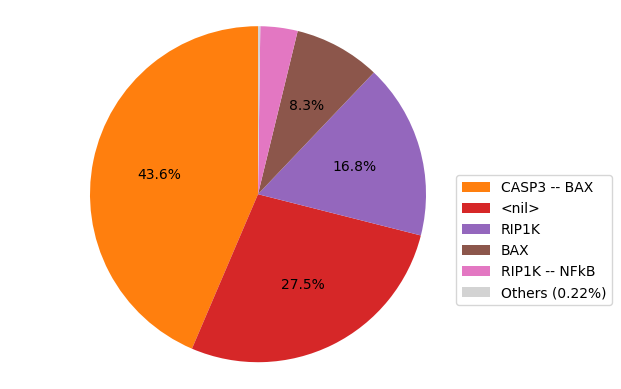

In [116]:
masim_tnf = maboss.load(tnf_simple_bnd, tnf_simple_cfg)

for node in list(masim_tnf.network.keys()):
    masim_tnf.network.set_istate(node, [0.5, 0.5])

masim_tnf.update_parameters(max_time=20, sample_count=10000)

masim_tnf.network.set_output(["BAX", "CASP3", "NFkB", "RIP1K"])

results_tnf = masim_tnf.run()

results_tnf.plot_piechart()

In [117]:
results_gpto4 = masim_gpto4.run()
results_gpt5 = masim_gpt5.run()
results_sonnet4 = masim_sonnet4.run()

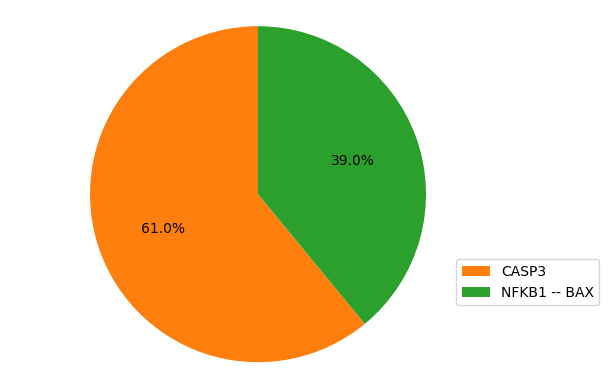

In [118]:
results_gpto4.plot_piechart()

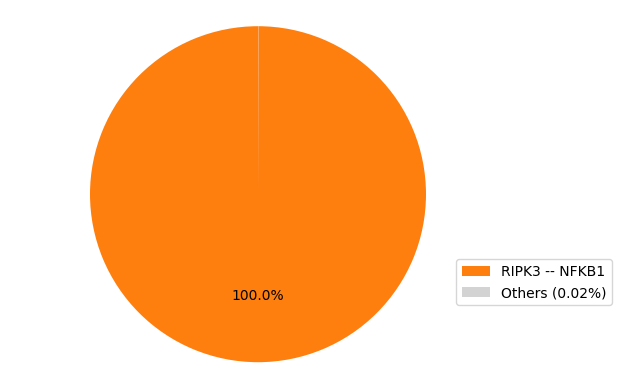

In [119]:
results_gpt5.plot_piechart()

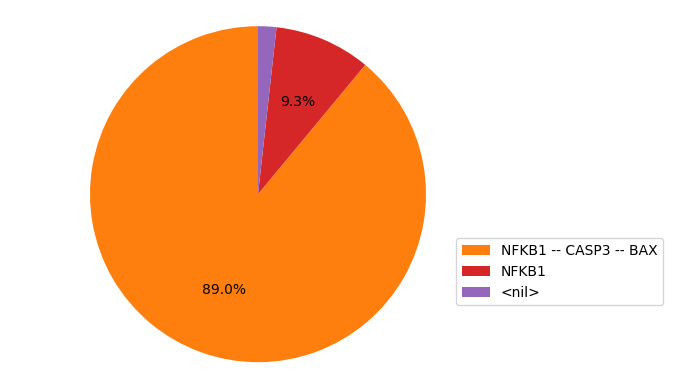

In [120]:
results_sonnet4.plot_piechart()

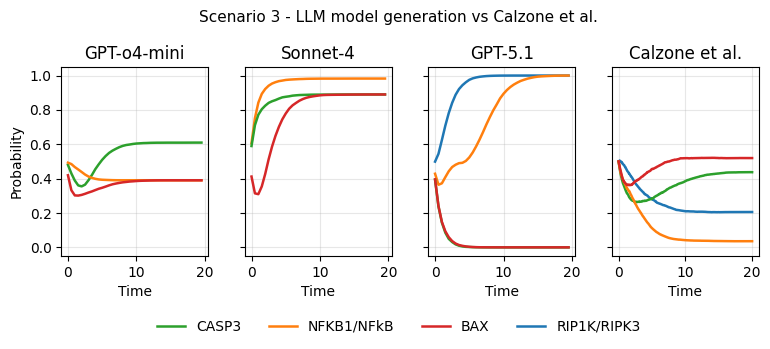

In [121]:
LABEL_ALIASES = {
    "NFkB":  "NFKB1/NFkB",
    "NFKB1": "NFKB1/NFkB",
    "RIP1K": "RIP1K/RIPK3",
    "RIPK3": "RIP1K/RIPK3",
}

def normalize_label(lab):
    return LABEL_ALIASES.get(lab, lab)

def new_figures_after(func):
    """Run func(); return fig objects created by it."""
    before = set(plt.get_fignums())
    func()
    after = set(plt.get_fignums())
    return [plt.figure(n) for n in sorted(after - before)]

def get_label(line):
    lab = line.get_label()
    return None if not lab or lab.startswith("_") else lab

def extract_model_data(figs):
    """Extract {normalized_label: (x, y)} from matplotlib figures.
    When two raw labels map to the same normalized label the first one wins."""
    data = {}
    for f in figs:
        for ax in f.axes:
            for ln in ax.get_lines():
                raw = get_label(ln)
                if raw:
                    lab = normalize_label(raw)
                    if lab not in data:          # keep first occurrence
                        data[lab] = (ln.get_xdata(), ln.get_ydata())
    return data

def build_color_map(*dicts):
    palette = ["#1f77b4","#ff7f0e","#2ca02c","#d62728",
               "#9467bd","#8c564b","#e377c2","#7f7f7f",
               "#bcbd22","#17becf"]
    all_labels = []
    for d in dicts:
        all_labels.extend(list(d.keys()))
    uniq_labels = list(OrderedDict.fromkeys(all_labels))
    return {lab: palette[i % len(palette)] for i, lab in enumerate(uniq_labels)}

# Generate plots (but don't show yet)
plt.ioff()
figs_gpt5      = new_figures_after(lambda: results_gpt5.plot_node_trajectory())
figs_gpto4     = new_figures_after(lambda: results_gpto4.plot_node_trajectory())
figs_sonnet4   = new_figures_after(lambda: results_sonnet4.plot_node_trajectory())
figs_tnf_simple = new_figures_after(lambda: results_tnf.plot_node_trajectory())
plt.ion()

# Extract data (labels already normalised inside extract_model_data)
data_gpt5      = extract_model_data(figs_gpt5)
data_gpto4     = extract_model_data(figs_gpto4)
data_sonnet4   = extract_model_data(figs_sonnet4)
data_tnf_simple = extract_model_data(figs_tnf_simple)

# Consistent colors across all panels
cmap = build_color_map(data_gpt5, data_gpto4, data_sonnet4, data_tnf_simple)
cmap.update({
    "CASP3":       "#2ca02c",  # green
    "NFKB1/NFkB":  "#ff7f0e",  # orange
    "BAX":         "#d62728",  # red
    "RIP1K/RIPK3": "#1f77b4",  # blue
})

# Build the 1×4 composite figure
fig, axes = plt.subplots(1, 4, figsize=(9, 3), sharey=True)
panels = [
    ("GPT-o4-mini",    data_gpto4,      axes[0]),
    ("Sonnet-4",       data_sonnet4,    axes[1]),
    ("GPT-5.1",        data_gpt5,       axes[2]),
    ("Calzone et al.", data_tnf_simple, axes[3]),
]

for title, dct, ax in panels:
    for lab, (x, y) in dct.items():
        ax.plot(x, y, label=lab, color=cmap[lab], linewidth=1.8)
    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Probability")

fig.suptitle("Scenario 3 - LLM model generation vs Calzone et al.", y=1.07, fontsize=11)

# Shared legend: collect unique handles from ALL axes
all_handles = {}
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    for handle, label in zip(h, l):
        if label not in all_handles:
            all_handles[label] = handle

fig.legend(all_handles.values(), all_handles.keys(),
           loc="lower center", ncol=len(all_handles), frameon=False,
           bbox_to_anchor=(0.5, -0.05))

plt.subplots_adjust(bottom=0.25, wspace=0.25)

# Close the original generated figures
for f in figs_gpto4 + figs_sonnet4 + figs_gpt5 + figs_tnf_simple:
    plt.close(f)

plt.show()


# Scenario 3 updated

In [77]:
output_gpt5 =  "updated_MCP/Gpt_5/Scenario_3/gpt_pruned/"


In [78]:
masim_gpt5_pruned = maboss.load(output_gpt5 + "output.bnd", output_gpt5 + "output.cfg")

masim_gpt5_pruned.network.set_output([ "CASP3", "RIPK3", "BAX", "NFKB1"])
masim_gpt5_pruned.param["max_time"]=20
masim_gpt5_pruned.param["thread_count"]=8

In [79]:
results_gpt5_pruned = masim_gpt5_pruned.run()


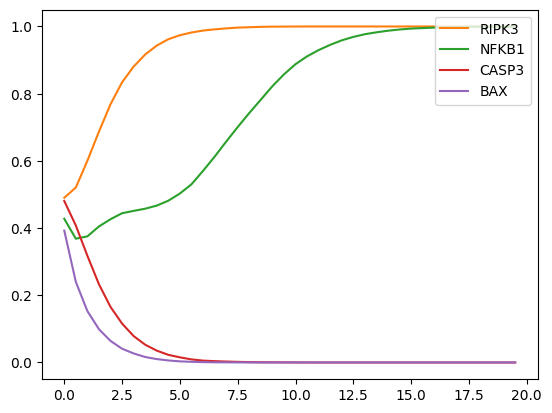

In [80]:
results_gpt5_pruned.plot_node_trajectory()

In [67]:
output_gpt5 =  "updated_MCP/Gpt_5/Scenario_3/gpt_rules_updated/"


In [33]:
masim_gpt5_rules_updated_new = maboss.load(output_gpt5 + "TNF_TCellFate_refined.bnd", output_gpt5 + "TNF_TCellFate_refined.cfg")
for node in list(masim_gpt5_rules_updated_new.network.keys()):
    masim_gpt5_rules_updated_new.network.set_istate(node, [0.5, 0.5])
masim_gpt5_rules_updated_new.network.set_output([ "CASP3", "RIPK3", "BAX", "NFKB1"])
masim_gpt5_rules_updated_new.param["max_time"]=20
masim_gpt5_rules_updated_new.param["thread_count"]=8

In [34]:
results_gpt5_rules_updated_new = masim_gpt5_rules_updated_new.run()

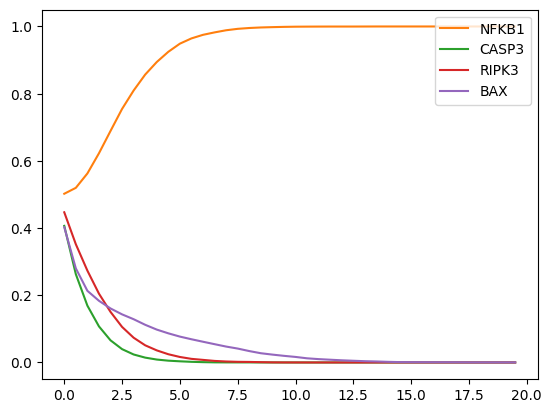

In [35]:
results_gpt5_rules_updated_new.plot_node_trajectory()

In [36]:
masim_gpt5_rules_updated_new.network.set_istate('TNF', [0, 1])

In [37]:
results_gpt5_rules_updated_new = masim_gpt5_rules_updated_new.run()

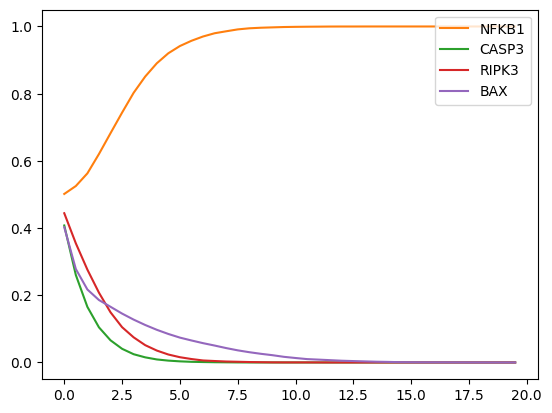

In [38]:
results_gpt5_rules_updated_new.plot_node_trajectory()

In [69]:
masim_gpt5_rules_updated_final = maboss.load(output_gpt5 + "TNF_cancer_fate_pruned_final.bnd", output_gpt5 + "TNF_cancer_fate_pruned_final.cfg")
for node in list(masim_gpt5_rules_updated_final.network.keys()):
    masim_gpt5_rules_updated_final.network.set_istate(node, [0.5, 0.5])
masim_gpt5_rules_updated_final.network.set_output([ "CASP3", "RIPK1", "BAX", "NFKB1"])
masim_gpt5_rules_updated_final.param["max_time"]=20
masim_gpt5_rules_updated_final.param["thread_count"]=8

In [70]:
results_gpt5_rules_updated_final = masim_gpt5_rules_updated_final.run()

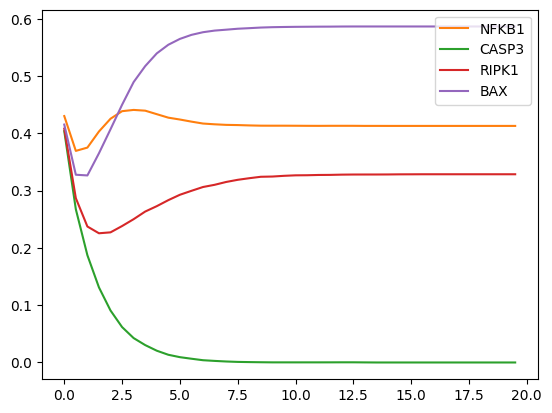

In [71]:
results_gpt5_rules_updated_final.plot_node_trajectory()

In [75]:
masim_gpt5_rules_updated_final.network.set_istate("TNF", [0.0, 1.0])

masim_gpt5_rules_updated_final.network.set_istate("TNFRSF1B", [0.0, 1.0])

masim_gpt5_rules_updated_final.network.set_istate("TNFRSF1A", [0.0, 1.0])

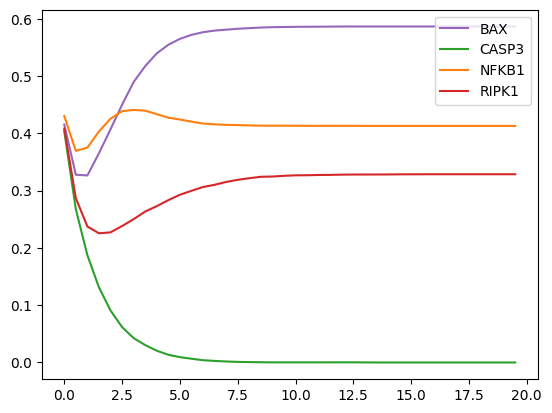

In [76]:
results_gpt5_rules_updated_final.plot_node_trajectory()

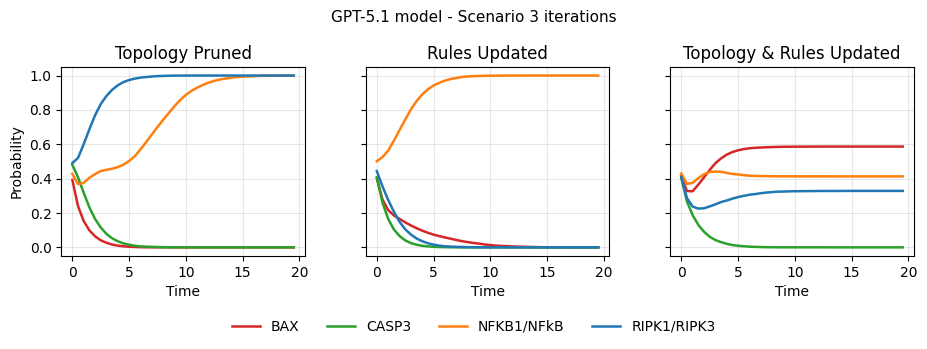

In [134]:
LABEL_ALIASES = {
    "NFkB":  "NFKB1/NFkB",
    "NFKB1": "NFKB1/NFkB",
    "RIPK1": "RIPK1/RIPK3",
    "RIPK3": "RIPK1/RIPK3",
}

def normalize_label(lab):
    return LABEL_ALIASES.get(lab, lab)

def new_figures_after(func):
    """Run func(); return fig objects created by it."""
    before = set(plt.get_fignums())
    func()
    after = set(plt.get_fignums())
    return [plt.figure(n) for n in sorted(after - before)]

def get_label(line):
    lab = line.get_label()
    return None if not lab or lab.startswith("_") else lab

def extract_model_data(figs):
    """Extract {normalized_label: (x, y)} from matplotlib figures.
    When two raw labels map to the same normalized label the first one wins."""
    data = {}
    for f in figs:
        for ax in f.axes:
            for ln in ax.get_lines():
                raw = get_label(ln)
                if raw:
                    lab = normalize_label(raw)
                    if lab not in data:          # keep first occurrence
                        data[lab] = (ln.get_xdata(), ln.get_ydata())
    return data

def build_color_map(*dicts):
    palette = ["#1f77b4","#ff7f0e","#2ca02c","#d62728",
               "#9467bd","#8c564b","#e377c2","#7f7f7f",
               "#bcbd22","#17becf"]
    all_labels = []
    for d in dicts:
        all_labels.extend(list(d.keys()))
    uniq_labels = list(OrderedDict.fromkeys(all_labels))
    return {lab: palette[i % len(palette)] for i, lab in enumerate(uniq_labels)}

# Generate plots (but don't show yet)
plt.ioff()
figs_gpt5_pruned            = new_figures_after(lambda: results_gpt5_pruned.plot_node_trajectory())
figs_gpt5_rules_updated     = new_figures_after(lambda: results_gpt5_rules_updated_new.plot_node_trajectory())
figs_gpt5_rules_updated_final = new_figures_after(lambda: results_gpt5_rules_updated_final.plot_node_trajectory())
plt.ion()

# Extract data (labels already normalised inside extract_model_data)
data_gpt5_pruned            = extract_model_data(figs_gpt5_pruned)
data_gpt5_rules_updated     = extract_model_data(figs_gpt5_rules_updated)
data_gpt5_rules_updated_final = extract_model_data(figs_gpt5_rules_updated_final)

# Consistent colors across all panels — fixed to match paper palette
cmap = build_color_map(data_gpt5_pruned, data_gpt5_rules_updated, data_gpt5_rules_updated_final)
cmap.update({
    "CASP3":       "#2ca02c",  # green
    "NFKB1/NFkB":  "#ff7f0e",  # orange
    "BAX":         "#d62728",  # red
    "RIPK1/RIPK3": "#1f77b4",  # blue
})

# Build the 1×3 composite figure
fig, axes = plt.subplots(1, 3, figsize=(11, 3), sharey=True)
panels = [
    ("Topology Pruned",        data_gpt5_pruned,             axes[0]),
    ("Rules Updated",          data_gpt5_rules_updated,      axes[1]),
    ("Topology & Rules Updated", data_gpt5_rules_updated_final, axes[2]),
]

for title, dct, ax in panels:
    for lab, (x, y) in dct.items():
        ax.plot(x, y, label=lab, color=cmap[lab], linewidth=1.8)
    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Probability")

fig.suptitle("GPT-5.1 model - Scenario 3 iterations", y=1.07, fontsize=11)

# Shared legend: collect unique handles from ALL axes
all_handles = {}
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    for handle, label in zip(h, l):
        if label not in all_handles:
            all_handles[label] = handle

fig.legend(all_handles.values(), all_handles.keys(),
           loc="lower center", ncol=len(all_handles), frameon=False,
           bbox_to_anchor=(0.5, -0.05))

plt.subplots_adjust(bottom=0.25, wspace=0.25)

# Close the original generated figures
for f in figs_gpt5_pruned + figs_gpt5_rules_updated + figs_gpt5_rules_updated_final:
    plt.close(f)

plt.show()


# LLM Performance Metrics — All Scenarios

In [141]:

# =============================================================================
# LLM Performance Metrics — Extract & Compile from updated_MCP CSVs + chat.jsons
# =============================================================================

import json
import pandas as pd
from pathlib import Path

BASE = Path("updated_MCP")

# ── per-scenario file map ──────────────────────────────────────────────────────
SCENARIOS = [
    ("GPT-5.1",     "Gpt_5",      "Scenario_1", "Gpt_5_Scenario_1_chat_summary.csv"),
    ("GPT-5.1",     "Gpt_5",      "Scenario_2", "Gpt_5_Scenario_2_chat_summary.csv"),
    ("GPT-5.1",     "Gpt_5",      "Scenario_3", "Gpt_5_Scenario_3_chat_summary.csv"),
    ("GPT-o4-mini", "Gpt_o4_mini","Scenario_1", "Gpt_o4_mini_Scenario_1_chat_summary.csv"),
    ("GPT-o4-mini", "Gpt_o4_mini","Scenario_2", "Gpt_o4_mini_Scenario_2_chat_summary.csv"),
    ("GPT-o4-mini", "Gpt_o4_mini","Scenario_3", "Gpt_o4_mini_Scenario_3_chat_summary.csv"),
    ("Sonnet-4",    "Sonnet_4",   "Scenario_1", "Sonnet_4_Scenario_1_chat_summary.csv"),
    ("Sonnet-4",    "Sonnet_4",   "Scenario_2", "Sonnet_4_Scenario_2_chat_summary.csv"),
    ("Sonnet-4",    "Sonnet_4",   "Scenario_3", "Sonnet_4_Scenario_3_chat_summary.csv"),
]

# ── helper: safe column lookup (handles mcp_ vs plain prefix variants) ─────────
def col(row, *names, default="N/A"):
    for n in names:
        if n in row.index and pd.notna(row[n]):
            return row[n]
    return default

# ── helper: classify intervention messages from chat.json ──────────────────────
def classify_interventions(chat_path: Path):
    """
    Returns a list of (type, snippet) tuples for each request AFTER the first.
    Types: 'max_tools_continue' | 'short_prompt' | 'confirmation'
    """
    if not chat_path.exists():
        return []
    with open(chat_path) as f:
        data = json.load(f)
    requests = data.get("requests", []) if isinstance(data, dict) else data
    results = []
    for req in requests[1:]:   # skip the initial user prompt (request 0)
        msg = req.get("message", {})
        parts = msg.get("parts", []) if isinstance(msg, dict) else []
        texts, is_agent = [], False
        for p in parts:
            if isinstance(p, dict):
                if "agent" in p:
                    is_agent = True
                if "text" in p:
                    texts.append(p["text"].strip())
        combined = " ".join(t for t in texts if t)
        lc = combined.lower().strip()
        if "try again" in lc:
            itype = "error_retry"
        elif "continue" in lc or is_agent:
            itype = "max_tools_continue"
        elif lc in ("yes", "yes please", "ok", "okay", "proceed", "go ahead"):
            itype = "confirmation"
        else:
            itype = "short_prompt"
        results.append((itype, combined[:80] if combined else "[button click]"))
    return results

# ── build the metrics table ────────────────────────────────────────────────────
records = []

for llm, folder, scenario, summary_csv in SCENARIOS:
    folder_path  = BASE / folder / scenario
    summary_path = folder_path / summary_csv

    if not summary_path.exists():
        print(f"[WARN] Not found: {summary_path}")
        continue

    df  = pd.read_csv(summary_path)
    row = df.iloc[0]

    # total retries from tool_metrics (sum of retry_count column)
    tm_files = list(folder_path.glob("*tool_metrics.csv"))
    total_retries = 0
    if tm_files:
        tm = pd.read_csv(tm_files[0])
        if "retry_count" in tm.columns:
            total_retries = int(tm["retry_count"].sum())

    n_cont   = sum(1 for t, _ in interventions if t == "max_tools_continue")
    n_conf   = sum(1 for t, _ in interventions if t == "confirmation")
    n_short  = sum(1 for t, _ in interventions if t == "short_prompt")
    n_err    = sum(1 for t, _ in interventions if t == "error_retry")

    parts_desc = []
    if n_err:   parts_desc.append(f"{n_err}x error retry")
    if n_cont:  parts_desc.append(f"{n_cont}x continue (max-tools)")
    if n_conf:  parts_desc.append(f"{n_conf}x confirmation")
    if n_short: parts_desc.append(f"{n_short}x short prompt")
    intervention_desc = "; ".join(parts_desc) if parts_desc else "—"

    wall_min   = round(float(col(row, "total_wall_time_s", default=0)) / 60, 1)
    prompt_tok = int(col(row, "total_prompt_tokens",     default=0))
    compl_tok  = int(col(row, "total_completion_tokens", default=0))
    total_tok  = int(col(row, "total_tokens",            default=0))
    tokens_str    = f"{total_tok:,}"                    if total_tok > 0 else "N/A"
    tokens_detail = f"{prompt_tok:,} / {compl_tok:,}"  if total_tok > 0 else "N/A"

    mcp_total   = int(col(row, "total_mcp_tool_calls", "total_tool_calls",   default=0))
    mcp_success = int(col(row, "total_mcp_tool_calls_success", "total_tool_calls_success", default=0))
    mcp_failed  = int(col(row, "total_mcp_tool_calls_failed",  "total_tool_calls_failed",  default=0))
    mcp_rate    = col(row, "mcp_tool_success_rate_pct", "tool_success_rate_pct", default="N/A")
    mcp_retries = max(total_retries,
                      int(col(row, "total_mcp_retries", "total_retries", default=0)))
    n_max_tools = int(col(row, "n_max_tools_exceeded", default=0))

    records.append({
        "LLM":                     llm,
        "Scenario":                scenario.replace("_", " "),
        "Wall Time (min)":         wall_min,
        "Prompt / Completion Tok": tokens_detail,
        "Total Tokens":            tokens_str,
        "User Interventions":      len(interventions),
        "Intervention Kind":       intervention_desc,
        "MCP Tool Calls":          mcp_total,
        "MCP Successes":           mcp_success,
        "MCP Failures":            mcp_failed,
        "Tool Success Rate (%)":   mcp_rate,
        "MCP Retries":             mcp_retries,
        "Max-Tools Events":        n_max_tools,
        "Outcome":                 "Success",
    })

metrics_df = pd.DataFrame(records)

print(metrics_df.to_string(index=False))
print(metrics_df.to_string(index=False))


        LLM   Scenario  Wall Time (min) Prompt / Completion Tok Total Tokens  User Interventions       Intervention Kind  MCP Tool Calls  MCP Successes  MCP Failures  Tool Success Rate (%)  MCP Retries  Max-Tools Events Outcome
    GPT-5.1 Scenario 1              7.0         119,701 / 3,343      123,044                   1 1x continue (max-tools)              34             34             0                  100.0            0                 0 Success
    GPT-5.1 Scenario 2              2.9          45,097 / 1,571       46,668                   1 1x continue (max-tools)              23             23             0                  100.0            0                 0 Success
    GPT-5.1 Scenario 3             70.6         107,875 / 2,723      110,598                   1 1x continue (max-tools)              52             52             0                  100.0            0                 1 Success
GPT-o4-mini Scenario 1              3.0                     N/A          N/A            

In [143]:

# =============================================================================
# User intervention detail — full message text per request
# =============================================================================
import json
from IPython.display import display

detail_rows = []
TYPE_LABEL = {
    "error_retry":        "Error retry",
    "max_tools_continue": "Max-tools continue",
    "confirmation":       "Confirmation",
    "short_prompt":       "Short prompt",
}

for llm, folder, scenario, _ in SCENARIOS:
    chat_path = BASE / folder / scenario / "chat.json"
    if not chat_path.exists():
        continue
    with open(chat_path) as f:
        data = json.load(f)
    requests = data.get("requests", []) if isinstance(data, dict) else data

    for req_idx, req in enumerate(requests):
        msg   = req.get("message", {})
        parts = msg.get("parts", []) if isinstance(msg, dict) else []
        texts, is_agent = [], False
        for p in parts:
            if isinstance(p, dict):
                if "agent" in p:
                    is_agent = True
                if "text" in p:
                    texts.append(p["text"].strip())
        combined = " ".join(t for t in texts if t)
        lc = combined.lower().strip()

        if req_idx == 0:
            itype = "initial_prompt"
        elif "try again" in lc:
            itype = "error_retry"
        elif "continue" in lc or is_agent:
            itype = "max_tools_continue"
        elif lc in ("yes", "yes please", "ok", "okay", "proceed", "go ahead"):
            itype = "confirmation"
        else:
            itype = "short_prompt"

        detail_rows.append({
            "LLM":      llm,
            "Scenario": scenario.replace("_", " "),
            "Req #":    req_idx + 1,
            "Type":     TYPE_LABEL.get(itype, itype.replace("_", " ").title()),
            "Message":  combined if combined else "[button click - no text]",
        })

detail_df = (pd.DataFrame(detail_rows)
               .query("Type != 'Initial Prompt'")
               .reset_index(drop=True))

# ── styled HTML ───────────────────────────────────────────────────────────────
TYPE_COLORS = {
    "Error retry":        "#f8d7da",
    "Max-tools continue": "#fff3cd",
    "Confirmation":       "#d4edda",
    "Short prompt":       "#cce5ff",
}

def color_type(val):
    bg = TYPE_COLORS.get(val, "white")
    return "background-color: " + bg + ";"

styled = (detail_df.style
    .map(color_type, subset=["Type"])
    .set_caption("User Interventions — Full Message Text (excluding initial prompt)")
    .set_table_styles([
        {"selector": "th", "props": [("background", "#2C7BB6"), ("color", "white"),
                                     ("font-weight", "bold"), ("font-size", "12px"),
                                     ("padding", "6px 10px")]},
        {"selector": "td", "props": [("padding", "5px 10px"), ("font-size", "11px"),
                                     ("vertical-align", "top")]},
        {"selector": "caption", "props": [("caption-side", "top"), ("font-size", "13px"),
                                          ("font-weight", "bold"), ("padding", "6px 0")]},
        {"selector": "td:last-child", "props": [("max-width", "500px"),
                                                 ("white-space", "pre-wrap"),
                                                 ("word-break", "break-word")]},
    ])
    .hide(axis="index")
)
display(styled)

# ── save to CSV ───────────────────────────────────────────────────────────────
detail_df.to_csv("llm_interventions_detail.csv", index=False)
print("Saved: llm_interventions_detail.csv")


LLM,Scenario,Req #,Type,Message
GPT-5.1,Scenario 1,2,Confirmation,yes please
GPT-5.1,Scenario 1,3,Confirmation,yes please
GPT-5.1,Scenario 1,4,Short prompt,Tune TNF resources
GPT-5.1,Scenario 3,2,Max-tools continue,"Continue: ""Continue to iterate?"""
GPT-o4-mini,Scenario 1,2,Short prompt,Proceed to the next phase.
GPT-o4-mini,Scenario 1,3,Short prompt,Export the physicell configuration
GPT-o4-mini,Scenario 3,2,Error retry,Try Again
Sonnet-4,Scenario 1,2,Max-tools continue,"Continue: ""Continue to iterate?"""
Sonnet-4,Scenario 1,3,Confirmation,yes please
Sonnet-4,Scenario 1,4,Max-tools continue,"Continue: ""Continue to iterate?"""


Saved: llm_interventions_detail.csv


LLM,Scenario,Wall Time (min),Prompt / Completion Tok,Total Tokens,User Interventions,Intervention Kind,MCP Tool Calls,MCP Successes,MCP Failures,Tool Success Rate (%),MCP Retries,Max-Tools Events,Outcome
GPT-5.1,Scenario 1,7.000000,"119,701 / 3,343","123,044",3,2x confirmation; 1x short prompt,34,34,0,100.000000,0,0,Success
GPT-5.1,Scenario 2,2.900000,"45,097 / 1,571","46,668",0,—,23,23,0,100.000000,0,0,Success
GPT-5.1,Scenario 3,70.600000,"107,875 / 2,723","110,598",1,1x continue (max-tools),52,52,0,100.000000,0,1,Success
GPT-o4-mini,Scenario 1,3.000000,N/A,N/A,2,2x short prompt,23,23,0,100.000000,0,0,Success
GPT-o4-mini,Scenario 2,1.200000,N/A,N/A,0,—,13,13,0,100.000000,0,0,Success
GPT-o4-mini,Scenario 3,9.600000,N/A,N/A,1,1x continue (max-tools),14,14,0,100.000000,0,0,Success
Sonnet-4,Scenario 1,12.600000,"199,096 / 2,448","201,544",3,2x continue (max-tools); 1x confirmation,37,37,0,100.000000,0,2,Success
Sonnet-4,Scenario 2,2.800000,"108,966 / 905","109,871",1,1x continue (max-tools),25,25,0,100.000000,0,1,Success
Sonnet-4,Scenario 3,40.000000,"130,761 / 1,199","131,960",1,1x continue (max-tools),56,56,0,100.000000,0,1,Success


Saved: llm_performance_metrics.csv
Saved: llm_performance_metrics.tex


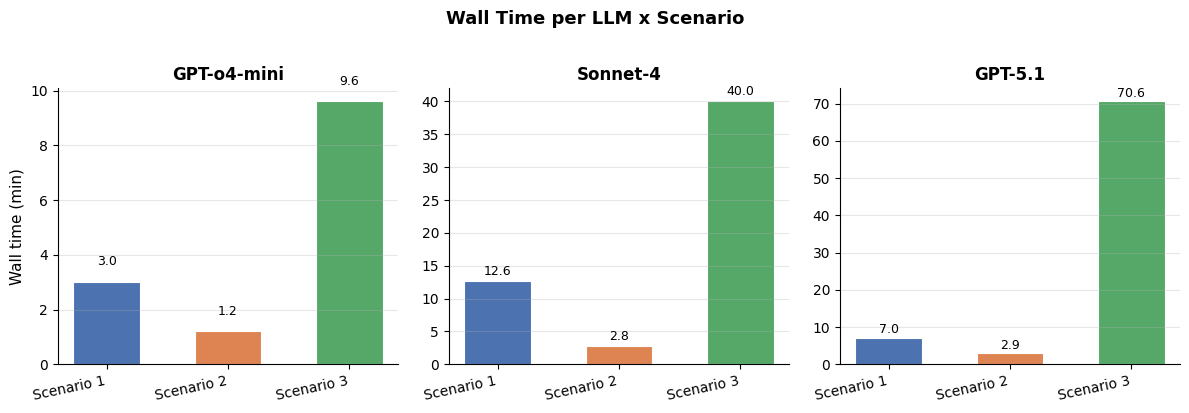

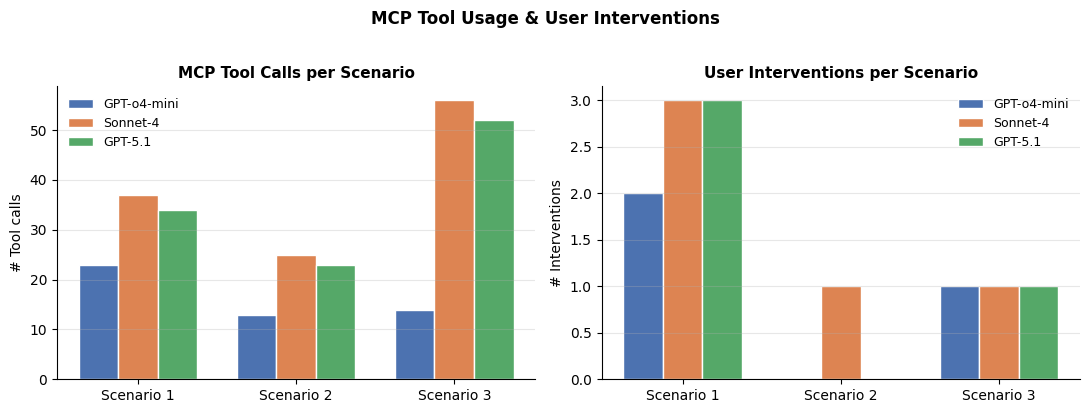

Saved: llm_wall_time_comparison.pdf/.png  and  llm_tool_interventions_comparison.pdf/.png


In [136]:

# =============================================================================
# Display styled table + export to CSV and LaTeX + bar charts
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np

# ── 1. Styled HTML table display ─────────────────────────────────────────────
display(metrics_df.style
    .set_caption("LLM Performance Metrics — All Scenarios")
    .set_table_styles([
        {"selector": "th", "props": [("background", "#2C7BB6"), ("color", "white"),
                                      ("font-weight", "bold"), ("font-size", "12px"),
                                      ("padding", "6px 10px"), ("text-align", "center")]},
        {"selector": "td", "props": [("padding", "5px 10px"), ("font-size", "11px"),
                                      ("text-align", "center")]},
        {"selector": "caption", "props": [("caption-side", "top"), ("font-size", "14px"),
                                           ("font-weight", "bold"), ("padding", "8px 0")]},
    ])
    .set_properties(**{"border": "1px solid #ddd"})
    .hide(axis="index")
)

# ── 2. CSV export ─────────────────────────────────────────────────────────────
csv_out = "llm_performance_metrics.csv"
metrics_df.to_csv(csv_out, index=False)
print(f"Saved: {csv_out}")

# ── 3. LaTeX export ───────────────────────────────────────────────────────────
def tex(s):
    return (str(s)
            .replace("\\", "\\textbackslash ")
            .replace("_",  "\\_")
            .replace("%",  "\\%")
            .replace("&",  "\\&")
            .replace("#",  "\\#"))

# columns to include in LaTeX: (df_col, align, latex_header)
cols_tex = [
    ("LLM",                    "l", "LLM"),
    ("Scenario",               "l", "Scenario"),
    ("Wall Time (min)",        "r", "Wall time (min)"),
    ("Total Tokens",           "r", "Total tokens"),
    ("Prompt / Completion Tok","r", "Prompt / compl.\\ tokens"),
    ("User Interventions",     "r", "Interventions"),
    ("Intervention Kind",      "l", "Intervention kind"),
    ("MCP Tool Calls",         "r", "MCP calls"),
    ("Tool Success Rate (%)","r",   "Success rate (\\%)"),
    ("MCP Retries",            "r", "Retries"),
    ("Max-Tools Events",       "r", "Max-tools"),
    ("Outcome",                "c", "Outcome"),
]

col_fmt  = "".join(c[1] for c in cols_tex)
col_hdrs = " & ".join(c[2] for c in cols_tex)

lines = [
    r"\begin{table*}[htbp]",
    r"\centering",
    (r"\caption{LLM performance metrics across all scenarios. "
     r"Wall time is accumulated server-side processing time. "
     r"Tokens are billed input/output tokens (N/A for GPT-o4-mini: not exported by the client). "
     r"Intervention kinds: \textit{continue (max-tools)} = VS~Code max-tool-limit button click; "
     r"\textit{confirmation} = short affirmative reply; \textit{short prompt} = brief user instruction.}"),
    r"\label{tab:llm_performance_metrics}",
    r"\small",
    r"\begin{tabular}{" + col_fmt + "}",
    r"\toprule",
    col_hdrs + r" \\",
    r"\midrule",
]

prev_llm = None
for _, row in metrics_df.iterrows():
    if row["LLM"] != prev_llm:
        if prev_llm is not None:
            lines.append(r"\midrule")
        prev_llm = row["LLM"]
    cells = " & ".join(tex(row[c[0]]) for c in cols_tex)
    lines.append(cells + r" \\")

lines += [r"\bottomrule", r"\end{tabular}", r"\end{table*}"]

latex_out = "llm_performance_metrics.tex"
from pathlib import Path
Path(latex_out).write_text("\n".join(lines))
print(f"Saved: {latex_out}")

# ── 4. Bar chart: Wall time ───────────────────────────────────────────────────
llms      = ["GPT-o4-mini", "Sonnet-4", "GPT-5.1"]
scenarios = ["Scenario 1", "Scenario 2", "Scenario 3"]
colors    = ["#4C72B0", "#DD8452", "#55A868"]
x         = np.arange(len(scenarios))
width     = 0.55

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=False)
for ax, llm in zip(axes, llms):
    sub  = metrics_df[metrics_df["LLM"] == llm].set_index("Scenario")
    vals = [sub.loc[s, "Wall Time (min)"] if s in sub.index else 0 for s in scenarios]
    bars = ax.bar(x, vals, width, color=colors, edgecolor="white", linewidth=0.8)
    ax.set_title(llm, fontsize=12, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(scenarios, rotation=12, ha="right", fontsize=10)
    ax.set_ylabel("Wall time (min)" if ax is axes[0] else "", fontsize=11)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{v:.1f}", ha="center", va="bottom", fontsize=9)

fig.suptitle("Wall Time per LLM x Scenario", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("llm_wall_time_comparison.pdf", dpi=300, bbox_inches="tight")
plt.savefig("llm_wall_time_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# ── 5. Bar chart: MCP tool calls & User interventions ────────────────────────
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

llm_colors = {"GPT-o4-mini": "#4C72B0", "Sonnet-4": "#DD8452", "GPT-5.1": "#55A868"}
x2    = np.arange(len(scenarios))
w2    = 0.25

for col_key, ax, title, ylabel in [
    ("MCP Tool Calls",     ax1, "MCP Tool Calls per Scenario",       "# Tool calls"),
    ("User Interventions", ax2, "User Interventions per Scenario",   "# Interventions"),
]:
    for i, llm in enumerate(["GPT-o4-mini", "Sonnet-4", "GPT-5.1"]):
        sub  = metrics_df[metrics_df["LLM"] == llm].set_index("Scenario")
        vals = [sub.loc[s, col_key] if s in sub.index else 0 for s in scenarios]
        offset = (i - 1) * w2
        ax.bar(x2 + offset, vals, w2, label=llm, color=llm_colors[llm], edgecolor="white")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xticks(x2)
    ax.set_xticklabels(scenarios, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(fontsize=9, frameon=False)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

fig2.suptitle("MCP Tool Usage & User Interventions", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("llm_tool_interventions_comparison.pdf", dpi=300, bbox_inches="tight")
plt.savefig("llm_tool_interventions_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: llm_wall_time_comparison.pdf/.png  and  llm_tool_interventions_comparison.pdf/.png")
